# 07 日频 ARMA–GARCH、IGARCH 与 FIGARCH 家族

本 Notebook 在固定三个月交割合约的项目日收益上联合估计日频 ARMA(1,1)-GARCH、IGARCH 和 FIGARCH，并重算 15/30/60 分钟盘中模型作为自包含比较层。所有数据均从正式 `silver` 直接只读重建；不读取第 03、04 或 06 本 Notebook 的输出、缓存或隐藏状态。

## 1. 在做什么，以及经济意义

日频模型把一天的信息压缩成一个收益观察。与盘中模型相比，它损失了日内路径，却显著减少零收益和微观结构噪声。这里关心三件事：

- 日频 GARCH 的 `α+β` 是否仍接近 1，说明波动冲击跨日高度持续；
- 日频 FIGARCH 的 `d` 是否显著为正，支持跨日长记忆；
- 日频 Student-t 的 `ν` 是否高于盘中结果，表示时间聚合后尾部是否相对变薄。

比较仅针对入样本结构参数，不据此判断预测优劣。日频与盘中模型的真正预测比较要在第 09–12 项使用共同的样本外方差代理和损失函数完成。RB 是论文外扩展品种；FU 旧产品段与稳定重启段始终分别估计。

## 2. 论文公式、Table 5 与项目复现边界

论文对日频数据使用与盘中相同的联合 ARMA(1,1) 条件均值和三类方差模型，但脚注明确日收益**不去季节化**。日频 GARCH 为

$$
r_t=\mu+\gamma r_{t-1}+\epsilon_t+\theta\epsilon_{t-1},
\qquad
h_t=\omega+\alpha\epsilon_{t-1}^2+\beta h_{t-1},
$$

$$
\epsilon_t\mid\Omega_{t-1}\sim t_\nu(0,h_t).
$$

GARCH 施加 `α+β<1`，IGARCH 施加 `β=1-α`。FIGARCH(1,d,1) 为

$$
h_t=\omega+\beta h_{t-1}
+\left[1-\beta L-(1-\phi L)(1-L)^d\right]\epsilon_t^2.
$$

论文 Table 5 按品种分 Panel，展示 `γ、θ、α、β、φ、d、ν` 及括号内 t 值，不展示 `μ、ω`；全部日频模型使用 Student-t，没有 Table 4 的正态例外。原表少数星号与其 t 值不一致，本项目统一由双侧 p 值生成星号。

必须区分两个日收益持有期：

- 论文写作 `r_t=ln(P_t)-ln(P_{t-1})`，是跨日价格差，包含非交易时段变化，但没有说明 `P_t` 是收盘、结算还是最后记录价；
- 本项目已冻结为同日 225 个真实日盘分钟的 Session 内收益之和，每个 Session 单独由开盘锚定，因而不含夜盘、隔夜、晨休、午休或换月跨日跳空。

所以本项是 Table 5 的**模型方法复现**，不是完全相同持有期收益复刻。其他实现选择如下：

- Table 5 风格结果使用冻结的初始样本，保留最后 300/200 日样本外区间；
- 日收益不做日内季节化。只为数值稳定在优化器内部使用 `100 × 日对数收益`；`μ` 除以 100、`ω` 与 `h` 除以 10,000 即回到原始对数单位，结构参数与 t 值不变；
- ARMA 预样本创新为 0；按相邻已观察日期连续递推，假期、换月与 FU_legacy 已知缺口不生成收益也不重置状态；五个研究序列之间重置；
- GARCH 用 ARCH 份额与总持久性坐标保证 `α,β≥0` 且 `α+β≤0.999999`；IGARCH 用缩减参数化；
- FIGARCH 使用 `arch 8.0.0` 可行域与截断 1000。论文 Table 5 的 fuel oil `φ=-0.01` 表明其未披露约束与当前 `arch` 默认域并不完全一致；
- SciPy SLSQP、三个固定 MA 起点、标准化 Student-t 和 Bollerslev–Wooldridge 稳健协方差；Hessian 无效时报告 `t=NA`，不使用伪逆。

In [1]:
from __future__ import annotations

from datetime import date
import gc
import pathlib
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        sys.path.insert(0, str(candidate_root / "02_Futures_Lakehouse"))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path("E:/anaconda3/envs/latitude_env_v2/python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude_env_v2 环境解释器 {expected_python}，实际为 {current_python}"
)

import arch
from arch.univariate import FIGARCH, GARCH, StudentsT
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import scipy
from scipy.optimize import Bounds, LinearConstraint, minimize
from scipy.signal import lfilter
from scipy.special import gammaln
from scipy.stats import norm
import statsmodels
from statsmodels.tools.numdiff import approx_fprime, approx_hess
from IPython.display import Markdown, display

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from a00_03_notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 400)
pd.set_option("display.width", 220)

print(f"Python: {sys.executable}")
print(f"arch={arch.__version__}; SciPy={scipy.__version__}; statsmodels={statsmodels.__version__}")
print(f"项目根目录: {project_root}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
arch=8.0.0; SciPy=1.17.1; statsmodels=0.14.6
项目根目录: E:\Latitude_Analytics_v2
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

本项直接参与四张稳定 silver 表。先浏览权威 metadata，再建立 Dataset 与读取业务数据。

In [2]:
display_schema_metadata(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA,
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_variety_calendar,期货品种交易日历维度表,8,"exchange_code,underlying_code,trading_date","exchange_code,year,month",1.2.0
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与代码步骤

代码按以下顺序线性展开：

1. 构造固定三个月交割合约链并通过完整日盘 Session 门禁；
2. 一次分钟扫描同时生成 15/30/60 分钟和日收益；
3. 日收益保持未季节化；盘中比较层重新估计 135 个全文样本周期因子；
4. 按 300/200 日边界切出初始样本；
5. 重估 45 个盘中模型并估计 15 个日频模型，共 60 个联合似然；
6. 生成 Table 5、跨频率参数比较、稳健 t 值和独立公式门禁。

In [3]:
exchange_code = "XSGE"
sample_start = date(2010, 1, 4)
sample_end = date(2026, 8, 28)
zero_return_tolerance = 1e-12
daily_return_model_scale = 100.0

figarch_truncation = 1000
garch_persistence_cap = 0.999999
arma_absolute_bound = 0.999
optimizer_max_iterations = 1000
optimizer_ftol = 1e-8
optimization_feasibility_tolerance = 1e-7
hessian_condition_limit = 1e12
deterministic_theta_starts = (-0.25, 0.0, 0.25)

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), 300, "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), 200, "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), 200, "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), 300, "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "oos_days",
        "research_role",
    ],
)
sample_spec_df["sample_start"] = pd.to_datetime(sample_spec_df["sample_start"])
sample_spec_df["sample_end"] = pd.to_datetime(sample_spec_df["sample_end"])
series_order = sample_spec_df["series_id"].tolist()

interval_spec_df = pd.DataFrame(
    [
        ("15-min", 15, 15, 15),
        ("30-min", 30, 8, 15),
        ("60-min", 60, 4, 45),
        ("Daily", 225, 1, 225),
    ],
    columns=[
        "interval_label",
        "target_interval_minutes",
        "expected_daily_slots",
        "expected_last_slot_minutes",
    ],
)
intraday_interval_order = ["15-min", "30-min", "60-min"]
model_interval_order = ["Daily", *intraday_interval_order]
interval_order = interval_spec_df["interval_label"].tolist()
model_family_order = ["GARCH", "FIGARCH", "IGARCH"]

display(sample_spec_df)
display(interval_spec_df)
display(
    pd.DataFrame(
        [
            ("Daily", "100 × Session 内日对数收益", "不去季节化；模型方差除 10,000 回原单位"),
            ("15/30/60-min", "全文样本 r/S_n", "只服务自包含盘中比较"),
        ],
        columns=["scope", "model_input", "scale_rule"],
    )
)

,series_id,underlying_code,sample_start,sample_end,oos_days,research_role
0,AL,AL,2010-01-04,2026-08-28,300,论文品种
1,CU,CU,2010-01-04,2026-08-28,300,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,200,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,200,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,300,论文外扩展品种


,interval_label,target_interval_minutes,expected_daily_slots,expected_last_slot_minutes
0,15-min,15,15,15
1,30-min,30,8,15
2,60-min,60,4,45
3,Daily,225,1,225


,scope,model_input,scale_rule
0,Daily,100 × Session 内日对数收益,"不去季节化；模型方差除 10,000 回原单位"
1,15/30/60-min,全文样本 r/S_n,只服务自包含盘中比较


## 5. 直接 PyArrow 过滤读取与固定三个月合约链

表名、主键和分区从 Schema metadata 读取；字段投影使用权威 Arrow 字段。正式湖只读，不产生任何研究缓存。

In [4]:
source_schema_by_role = {
    "variety_calendar": FUTURES_VARIETY_CALENDAR_SCHEMA,
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,variety_calendar,dim_futures_variety_calendar,"exchange_code,underlying_code,trading_date","exchange_code,year,month",0
1,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
2,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
3,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [5]:
trading_date_field = ds.field("trading_date")
underlying_field = ds.field("underlying_code")
base_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
)
main_series_filter = (
    underlying_field.isin(["AL", "CU", "RB"])
    & (trading_date_field >= pa.scalar(sample_start, type=pa.date32()))
    & (trading_date_field <= pa.scalar(sample_end, type=pa.date32()))
)
fu_series_filter = (
    (underlying_field == "FU")
    & (
        (
            (trading_date_field >= pa.scalar(date(2010, 1, 4), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2011, 9, 30), type=pa.date32()))
        )
        | (
            (trading_date_field >= pa.scalar(date(2020, 1, 2), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2026, 8, 28), type=pa.date32()))
        )
    )
)
research_sample_filter = base_filter & (main_series_filter | fu_series_filter)

variety_columns = [
    "underlying_code",
    "exchange_code",
    "trading_date",
    "active_contract_count",
]
variety_projection_schema = pa.schema(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA.field(column_name)
        for column_name in variety_columns
    ]
)
variety_calendar_table = source_dataset_by_role["variety_calendar"].to_table(
    columns=variety_columns,
    filter=research_sample_filter,
)
validated_variety_calendar_table = validate_arrow_table(
    variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df = arrow_to_pandas(
    validated_variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df["trading_date"] = pd.to_datetime(
    variety_calendar_df["trading_date"]
)

expected_sample_pieces = []
for sample_spec in sample_spec_df.itertuples(index=False):
    expected_series_df = variety_calendar_df.loc[
        (variety_calendar_df["underlying_code"] == sample_spec.underlying_code)
        & (variety_calendar_df["trading_date"] >= sample_spec.sample_start)
        & (variety_calendar_df["trading_date"] <= sample_spec.sample_end)
    ].copy()
    expected_series_df.insert(0, "series_id", sample_spec.series_id)
    expected_sample_pieces.append(expected_series_df)

expected_sample_df = pd.concat(
    expected_sample_pieces,
    ignore_index=True,
).sort_values(["series_id", "trading_date"], ignore_index=True)

target_delivery_period = (
    pd.PeriodIndex(expected_sample_df["trading_date"], freq="M") + 3
)
expected_sample_df["target_delivery_year"] = target_delivery_period.year
expected_sample_df["target_delivery_month"] = target_delivery_period.month
expected_sample_df["expected_contract_code"] = (
    expected_sample_df["underlying_code"].astype("string")
    + expected_sample_df["target_delivery_year"].mod(100).astype("string").str.zfill(2)
    + expected_sample_df["target_delivery_month"].astype("string").str.zfill(2)
    + "."
    + expected_sample_df["exchange_code"].astype("string")
)

display(
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(
        expected_trading_days="size",
        first_date="min",
        last_date="max",
    )
    .reset_index()
)

,series_id,expected_trading_days,first_date,last_date
0,AL,4045,2010-01-04,2026-08-28
1,CU,4045,2010-01-04,2026-08-28
2,FU_legacy,426,2010-01-04,2011-09-30
3,FU_relaunched,1614,2020-01-02,2026-08-28
4,RB,4045,2010-01-04,2026-08-28


In [6]:
contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "session_start_at",
    "session_end_at",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name)
        for column_name in contract_columns
    ]
)
day_contract_filter = research_sample_filter & (
    ds.field("is_night_session") == False
)
contract_calendar_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=day_contract_filter,
)
validated_contract_calendar_table = validate_arrow_table(
    contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(
    contract_calendar_df["trading_date"]
)

contract_code_parts = contract_calendar_df["contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
if not contract_code_parts.notna().all().all():
    invalid_contract_codes = contract_calendar_df.loc[
        contract_code_parts.isna().any(axis=1),
        "contract_code",
    ].drop_duplicates()
    raise ValueError(
        f"发现无法解析的固定月份合约代码: {invalid_contract_codes.tolist()}"
    )

contract_calendar_df["code_underlying"] = contract_code_parts[0]
contract_calendar_df["delivery_year"] = (
    2000 + contract_code_parts[1].str[:2].astype("int16")
)
contract_calendar_df["delivery_month"] = (
    contract_code_parts[1].str[2:].astype("int8")
)
contract_calendar_df["code_exchange"] = contract_code_parts[2]
trade_plus_three_period = (
    pd.PeriodIndex(contract_calendar_df["trading_date"], freq="M") + 3
)
contract_calendar_df["is_target_delivery"] = (
    contract_calendar_df["delivery_year"].eq(trade_plus_three_period.year)
    & contract_calendar_df["delivery_month"].eq(trade_plus_three_period.month)
)

assert (
    contract_calendar_df["code_underlying"]
    == contract_calendar_df["underlying_code"]
).all()
assert (
    contract_calendar_df["code_exchange"]
    == contract_calendar_df["exchange_code"]
).all()
assert not contract_calendar_df["is_night_session"].any()

target_session_df = contract_calendar_df.loc[
    contract_calendar_df["is_target_delivery"]
].copy()
target_contract_count_df = (
    target_session_df.groupby(
        ["underlying_code", "trading_date"],
        observed=True,
    )["contract_code"]
    .nunique()
    .rename("target_contract_count")
    .reset_index()
)
target_contract_day_df = (
    target_session_df.groupby(
        [
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        day_minute_count=("minute_count", "sum"),
    )
    .reset_index()
)

contract_mapping_audit_df = expected_sample_df.merge(
    target_contract_count_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["target_contract_count"] = (
    contract_mapping_audit_df["target_contract_count"]
    .fillna(0)
    .astype("int64")
)
assert contract_mapping_audit_df["target_contract_count"].le(1).all()

contract_mapping_audit_df = contract_mapping_audit_df.merge(
    target_contract_day_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["mapping_status"] = np.where(
    contract_mapping_audit_df["contract_code"].notna(),
    "selected",
    "excluded_target_contract_not_listed",
)
missing_contract_mapping_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] != "selected",
    [
        "series_id",
        "trading_date",
        "expected_contract_code",
        "target_contract_count",
        "mapping_status",
    ],
].copy()

known_missing_keys_df = expected_sample_df.loc[
    (expected_sample_df["series_id"] == "FU_legacy")
    & (
        expected_sample_df["trading_date"].dt.to_period("M")
        == pd.Period("2010-11")
    ),
    ["series_id", "trading_date", "expected_contract_code"],
].sort_values(["series_id", "trading_date"], ignore_index=True)
actual_missing_keys_df = missing_contract_mapping_df[
    ["series_id", "trading_date", "expected_contract_code"]
].sort_values(["series_id", "trading_date"], ignore_index=True)
assert actual_missing_keys_df.equals(known_missing_keys_df)
assert set(actual_missing_keys_df["expected_contract_code"]) == {
    "FU1102.XSGE"
}

contract_series_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] == "selected"
].copy()
contract_series_df = contract_series_df.sort_values(
    ["series_id", "trading_date"],
    ignore_index=True,
)
contract_series_df["previous_contract_code"] = (
    contract_series_df.groupby(
        "series_id",
        observed=True,
    )["contract_code"].shift()
)
contract_series_df["is_roll_day"] = (
    contract_series_df["previous_contract_code"].notna()
    & contract_series_df["contract_code"].ne(
        contract_series_df["previous_contract_code"]
    )
).astype("bool")

selected_target_session_df = target_session_df.merge(
    contract_series_df[
        [
            "series_id",
            "underlying_code",
            "trading_date",
            "contract_code",
            "delivery_year",
            "delivery_month",
            "is_roll_day",
        ]
    ],
    on=[
        "underlying_code",
        "trading_date",
        "contract_code",
        "delivery_year",
        "delivery_month",
    ],
    how="inner",
    validate="many_to_one",
)
assert selected_target_session_df.groupby(
    ["series_id", "trading_date"],
    observed=True,
)["session_number"].nunique().eq(3).all()

display(missing_contract_mapping_df)
display(
    contract_series_df.groupby("series_id", observed=True)
    .agg(
        selected_trading_days=("trading_date", "size"),
        first_selected_date=("trading_date", "min"),
        last_selected_date=("trading_date", "max"),
        unique_contracts=("contract_code", "nunique"),
        roll_days=("is_roll_day", "sum"),
    )
    .reset_index()
)

,series_id,trading_date,expected_contract_code,target_contract_count,mapping_status
8287,FU_legacy,2010-11-01,FU1102.XSGE,0,excluded_target_contract_not_listed
8288,FU_legacy,2010-11-02,FU1102.XSGE,0,excluded_target_contract_not_listed
8289,FU_legacy,2010-11-03,FU1102.XSGE,0,excluded_target_contract_not_listed
8290,FU_legacy,2010-11-04,FU1102.XSGE,0,excluded_target_contract_not_listed
8291,FU_legacy,2010-11-05,FU1102.XSGE,0,excluded_target_contract_not_listed
8292,FU_legacy,2010-11-08,FU1102.XSGE,0,excluded_target_contract_not_listed
8293,FU_legacy,2010-11-09,FU1102.XSGE,0,excluded_target_contract_not_listed
8294,FU_legacy,2010-11-10,FU1102.XSGE,0,excluded_target_contract_not_listed
8295,FU_legacy,2010-11-11,FU1102.XSGE,0,excluded_target_contract_not_listed
8296,FU_legacy,2010-11-12,FU1102.XSGE,0,excluded_target_contract_not_listed


,series_id,selected_trading_days,first_selected_date,last_selected_date,unique_contracts,roll_days
0,AL,4045,2010-01-04,2026-08-28,200,199
1,CU,4045,2010-01-04,2026-08-28,200,199
2,FU_legacy,404,2010-01-04,2011-09-30,20,19
3,FU_relaunched,1614,2020-01-02,2026-08-28,80,79
4,RB,4045,2010-01-04,2026-08-28,200,199


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
day_bar_filter = (
    research_sample_filter
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
)
bar_calendar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=day_bar_filter,
)
validated_bar_calendar_table = validate_arrow_table(
    bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df = arrow_to_pandas(
    validated_bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df["trading_date"] = pd.to_datetime(
    bar_calendar_df["trading_date"]
)

bar_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
selected_bar_session_df = selected_target_session_df[
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
        "minute_count",
    ]
].merge(
    bar_calendar_df,
    on=bar_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
selected_bar_session_df["eligible_session"] = (
    selected_bar_session_df["_merge"].eq("both")
    & selected_bar_session_df["is_fetch_required"].eq(True)
    & selected_bar_session_df["is_fetch_completed"].eq(True)
    & selected_bar_session_df["expected_bar_count"].eq(
        selected_bar_session_df["actual_bar_count"]
    )
    & selected_bar_session_df["missing_bar_count"].eq(0)
)

selected_day_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]
complete_contract_day_df = (
    selected_bar_session_df.groupby(
        selected_day_key,
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        upstream_session_rows=("bar_frequency", "count"),
        eligible_session_count=("eligible_session", "sum"),
        expected_minute_rows=("expected_bar_count", "sum"),
        actual_minute_rows=("actual_bar_count", "sum"),
        missing_minute_rows=("missing_bar_count", "sum"),
    )
    .reset_index()
)
complete_contract_day_df["is_complete_contract_day"] = (
    complete_contract_day_df["day_session_count"].eq(3)
    & complete_contract_day_df["upstream_session_rows"].eq(3)
    & complete_contract_day_df["eligible_session_count"].eq(3)
    & complete_contract_day_df["expected_minute_rows"].eq(225)
    & complete_contract_day_df["actual_minute_rows"].eq(225)
    & complete_contract_day_df["missing_minute_rows"].eq(0)
)

complete_day_keys_df = complete_contract_day_df.loc[
    complete_contract_day_df["is_complete_contract_day"],
    selected_day_key,
].copy()
complete_session_keys_df = selected_bar_session_df.merge(
    complete_day_keys_df,
    on=selected_day_key,
    how="inner",
    validate="many_to_one",
)
complete_session_keys_df = complete_session_keys_df.loc[
    complete_session_keys_df["eligible_session"]
].copy()
complete_session_keys_df["calendar_year"] = (
    complete_session_keys_df["trading_date"].dt.year.astype("int16")
)

coverage_df = (
    contract_series_df.groupby("series_id", observed=True)
    .agg(selected_contract_days=("trading_date", "size"))
    .reset_index()
    .merge(
        complete_contract_day_df.groupby("series_id", observed=True)
        ["is_complete_contract_day"]
        .sum()
        .rename("complete_contract_days")
        .reset_index(),
        on="series_id",
        validate="one_to_one",
    )
)
coverage_df["complete_pct"] = (
    100
    * coverage_df["complete_contract_days"]
    / coverage_df["selected_contract_days"]
)
display(coverage_df.round(4))

,series_id,selected_contract_days,complete_contract_days,complete_pct
0,AL,4045,4045,100.0
1,CU,4045,4045,100.0
2,FU_legacy,404,404,100.0
3,FU_relaunched,1614,1614,100.0
4,RB,4045,4045,100.0


## 6. 一次分钟扫描生成盘中与日收益

`Daily` 槽直接汇总同日 225 个 Session 内一分钟收益；它与 15/30/60 分钟槽的逐日加总必须一致。由于每个 Session 首分钟都由本 Session 的 `open` 锚定，该日收益不含三个 Session 之间的价格跳变。

In [8]:
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "close",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
    "expected_bar_count",
]
multiscale_return_pieces = []
minute_read_audit_rows = []
slot_audit_rows = []

for (
    series_id,
    calendar_year,
), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"],
    observed=True,
    sort=True,
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(
        minute_session_join_key
    ).any()

    underlying_codes = (
        partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    )
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = (
        partition_session_keys_df["contract_code"].drop_duplicates().tolist()
    )

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (
            ds.field("trading_date")
            >= pa.scalar(partition_first_date.date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(partition_last_date.date(), type=pa.date32())
        )
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(
        minute_partition_df["trading_date"]
    )

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    )
    selected_minute_df = selected_minute_df.sort_values(
        [
            "series_id",
            "trading_date",
            "contract_code",
            "bar_at",
        ],
        ignore_index=True,
    )
    for price_column in ["open", "close"]:
        selected_minute_df[price_column] = pd.to_numeric(
            selected_minute_df[price_column]
        ).astype("float64")

    price_values = selected_minute_df[["open", "close"]].to_numpy()
    assert np.isfinite(price_values).all()
    assert (price_values > 0).all()

    observed_session_rows_df = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = (
        session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    )
    misaligned_session_count = int(
        (
            session_alignment_df["expected_bar_count"]
            != session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )["close"].shift()
    )
    first_minute_mask = selected_minute_df[
        "minute_position_within_session"
    ].eq(1)
    assert selected_minute_df.loc[
        first_minute_mask,
        "previous_close_within_session",
    ].isna().all()
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    assert np.allclose(
        selected_minute_df.loc[
            first_minute_mask,
            "return_reference_price",
        ],
        selected_minute_df.loc[first_minute_mask, "open"],
    )
    selected_minute_df["minute_log_return"] = np.log(
        selected_minute_df["close"]
        / selected_minute_df["return_reference_price"]
    )
    assert np.isfinite(selected_minute_df["minute_log_return"]).all()

    daily_group_key = [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
    ]
    selected_minute_df["trading_minute_ordinal"] = (
        selected_minute_df.groupby(
            daily_group_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    day_minute_count_series = selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    ).size()
    assert day_minute_count_series.eq(225).all()
    assert selected_minute_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    )["trading_minute_ordinal"].max().eq(225).all()

    partition_contract_days = int(day_minute_count_series.size)
    partition_interval_rows = 0

    for interval_spec in interval_spec_df.itertuples(index=False):
        selected_minute_df["interval_slot"] = (
            (
                selected_minute_df["trading_minute_ordinal"] - 1
            )
            // interval_spec.target_interval_minutes
            + 1
        )
        interval_return_df = (
            selected_minute_df.groupby(
                daily_group_key + ["interval_slot"],
                observed=True,
                sort=True,
            )
            .agg(
                interval_return=("minute_log_return", "sum"),
                actual_interval_minutes=("minute_log_return", "size"),
                session_span_count=("session_number", "nunique"),
                first_bar_at=("bar_at", "min"),
                last_bar_at=("bar_at", "max"),
            )
            .reset_index()
        )
        interval_return_df["interval_label"] = (
            interval_spec.interval_label
        )
        interval_return_df["target_interval_minutes"] = (
            interval_spec.target_interval_minutes
        )
        interval_return_df["is_zero_return"] = np.isclose(
            interval_return_df["interval_return"],
            0.0,
            atol=zero_return_tolerance,
            rtol=0.0,
        )

        interval_day_audit_df = (
            interval_return_df.groupby(
                daily_group_key,
                observed=True,
                sort=True,
            )
            .agg(
                observed_slots=("interval_slot", "size"),
                maximum_slot=("interval_slot", "max"),
                total_aggregated_minutes=(
                    "actual_interval_minutes",
                    "sum",
                ),
            )
            .reset_index()
        )
        last_slot_df = (
            interval_return_df.sort_values(
                daily_group_key + ["interval_slot"]
            )
            .groupby(
                daily_group_key,
                observed=True,
                sort=False,
            )
            .tail(1)
        )
        non_last_slot_df = interval_return_df.merge(
            last_slot_df[daily_group_key + ["interval_slot"]],
            on=daily_group_key + ["interval_slot"],
            how="left",
            indicator=True,
            validate="one_to_one",
        )
        non_last_slot_df = non_last_slot_df.loc[
            non_last_slot_df["_merge"] == "left_only"
        ]

        slot_audit_rows.append(
            {
                "series_id": series_id,
                "calendar_year": int(calendar_year),
                "interval_label": interval_spec.interval_label,
                "contract_days": partition_contract_days,
                "return_observations": len(interval_return_df),
                "slot_count_failures": int(
                    interval_day_audit_df["observed_slots"]
                    .ne(interval_spec.expected_daily_slots)
                    .sum()
                ),
                "aggregated_minute_count_failures": int(
                    interval_day_audit_df["total_aggregated_minutes"]
                    .ne(225)
                    .sum()
                ),
                "non_last_slot_length_failures": int(
                    non_last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.target_interval_minutes)
                    .sum()
                ),
                "last_slot_length_failures": int(
                    last_slot_df["actual_interval_minutes"]
                    .ne(interval_spec.expected_last_slot_minutes)
                    .sum()
                ),
                "cross_session_intervals": int(
                    interval_return_df["session_span_count"].gt(1).sum()
                ),
            }
        )

        assert interval_day_audit_df["observed_slots"].eq(
            interval_spec.expected_daily_slots
        ).all()
        assert interval_day_audit_df[
            "total_aggregated_minutes"
        ].eq(225).all()
        assert non_last_slot_df["actual_interval_minutes"].eq(
            interval_spec.target_interval_minutes
        ).all()
        assert last_slot_df["actual_interval_minutes"].eq(
            interval_spec.expected_last_slot_minutes
        ).all()

        multiscale_return_pieces.append(interval_return_df)
        partition_interval_rows += len(interval_return_df)

    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(
                partition_session_keys_df["expected_bar_count"].sum()
            ),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "contract_days": partition_contract_days,
            "multiscale_return_rows": partition_interval_rows,
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        interval_return_df,
        interval_day_audit_df,
        last_slot_df,
        non_last_slot_df,
    )
    gc.collect()

multiscale_return_df = pd.concat(
    multiscale_return_pieces,
    ignore_index=True,
)
multiscale_return_df["interval_label"] = pd.Categorical(
    multiscale_return_df["interval_label"],
    categories=interval_order,
    ordered=True,
)
multiscale_return_df = multiscale_return_df.sort_values(
    [
        "series_id",
        "interval_label",
        "trading_date",
        "interval_slot",
    ],
    ignore_index=True,
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)
slot_audit_df = pd.DataFrame(slot_audit_rows)

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        contract_days=("contract_days", "sum"),
        multiscale_return_rows=("multiscale_return_rows", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,contract_days,multiscale_return_rows,elapsed_seconds
0,AL,17,13026480,910125,910125,0,12135,4045,113260,19.321
1,CU,17,13026705,910125,910125,0,12135,4045,113260,18.260
2,FU_legacy,2,654075,90900,90900,0,1212,404,11312,1.100
3,FU_relaunched,7,4182780,363150,363150,0,4842,1614,45192,6.294
4,RB,17,10305705,910125,910125,0,12135,4045,113260,15.740


## 7. 未季节化日收益、盘中周期因子与初始样本

日频输入直接取 `100 × daily_log_return`。盘中比较层仍按论文公式

$$
S_n=\sqrt{\operatorname{mean}_t(r_{t,n}^2)},\qquad
\widetilde r_{t,n}=r_{t,n}/S_n
$$

在全文样本估计因子，明确含前视；它不进入日频模型。

In [9]:
daily_group_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]

daily_return_df = (
    multiscale_return_df.loc[
        multiscale_return_df["interval_label"] == "Daily",
        daily_group_key + ["interval_return", "actual_interval_minutes"],
    ]
    .rename(columns={"interval_return": "daily_log_return"})
    .sort_values(["series_id", "trading_date"], ignore_index=True)
)
daily_return_df["daily_model_return"] = (
    daily_return_model_scale * daily_return_df["daily_log_return"]
)
daily_return_df["is_zero_return"] = np.isclose(
    daily_return_df["daily_log_return"],
    0.0,
    atol=zero_return_tolerance,
    rtol=0.0,
)

daily_consistency_df = (
    multiscale_return_df.groupby(
        ["series_id", "contract_code", "trading_date", "interval_label"],
        observed=True,
        sort=True,
    )["interval_return"]
    .sum()
    .unstack("interval_label")
    .reset_index()
)
for interval_label in intraday_interval_order:
    daily_consistency_df[f"{interval_label}_minus_Daily"] = (
        daily_consistency_df[interval_label] - daily_consistency_df["Daily"]
    )
daily_consistency_error_columns = [
    f"{interval_label}_minus_Daily"
    for interval_label in intraday_interval_order
]

intraday_return_df = multiscale_return_df.loc[
    multiscale_return_df["interval_label"].isin(intraday_interval_order)
].copy()
intraday_return_df["squared_return"] = intraday_return_df["interval_return"] ** 2
seasonality_group_key = ["series_id", "interval_label", "interval_slot"]
seasonality_factor_df = (
    intraday_return_df.groupby(
        seasonality_group_key,
        observed=True,
        sort=True,
    )
    .agg(
        factor_observations=("interval_return", "size"),
        mean_squared_return=("squared_return", "mean"),
        target_interval_minutes=("target_interval_minutes", "first"),
        minimum_actual_minutes=("actual_interval_minutes", "min"),
        maximum_actual_minutes=("actual_interval_minutes", "max"),
    )
    .reset_index()
)
seasonality_factor_df["seasonality_factor"] = np.sqrt(
    seasonality_factor_df["mean_squared_return"]
)
seasonal_return_df = intraday_return_df.merge(
    seasonality_factor_df[
        seasonality_group_key + ["factor_observations", "seasonality_factor"]
    ],
    on=seasonality_group_key,
    how="left",
    validate="many_to_one",
)
seasonal_return_df["deseasonalized_return"] = (
    seasonal_return_df["interval_return"]
    / seasonal_return_df["seasonality_factor"]
)
full_sample_factor_audit_df = (
    seasonal_return_df.groupby(
        seasonality_group_key,
        observed=True,
        sort=True,
    )["deseasonalized_return"]
    .apply(lambda values: np.mean(np.square(values)))
    .rename("mean_squared_deseasonalized_return")
    .reset_index()
)

model_sample_rows = []
for sample_spec in sample_spec_df.itertuples(index=False):
    series_dates = np.sort(
        daily_return_df.loc[
            daily_return_df["series_id"] == sample_spec.series_id,
            "trading_date",
        ].unique()
    )
    assert len(series_dates) > sample_spec.oos_days
    initial_dates = series_dates[: -sample_spec.oos_days]
    oos_dates = series_dates[-sample_spec.oos_days :]
    model_sample_rows.append(
        {
            "series_id": sample_spec.series_id,
            "selected_days": len(series_dates),
            "initial_sample_days": len(initial_dates),
            "oos_days": len(oos_dates),
            "initial_sample_start": pd.Timestamp(initial_dates[0]),
            "initial_sample_end": pd.Timestamp(initial_dates[-1]),
            "oos_start": pd.Timestamp(oos_dates[0]),
            "oos_end": pd.Timestamp(oos_dates[-1]),
        }
    )
model_sample_df = pd.DataFrame(model_sample_rows)

daily_model_df = daily_return_df.merge(
    model_sample_df[["series_id", "initial_sample_end"]],
    on="series_id",
    how="left",
    validate="many_to_one",
)
daily_model_df = daily_model_df.loc[
    daily_model_df["trading_date"].le(daily_model_df["initial_sample_end"])
].sort_values(["series_id", "trading_date"], ignore_index=True)

intraday_model_df = seasonal_return_df.merge(
    model_sample_df[["series_id", "initial_sample_end"]],
    on="series_id",
    how="left",
    validate="many_to_one",
)
intraday_model_df = intraday_model_df.loc[
    intraday_model_df["trading_date"].le(
        intraday_model_df["initial_sample_end"]
    )
].sort_values(
    ["series_id", "interval_label", "trading_date", "interval_slot"],
    ignore_index=True,
)

daily_panel_audit_df = (
    daily_model_df.groupby("series_id", observed=True, sort=True)
    .agg(
        initial_sample_days=("trading_date", "nunique"),
        input_returns=("daily_model_return", "size"),
        first_date=("trading_date", "min"),
        last_date=("trading_date", "max"),
        zero_returns=("is_zero_return", "sum"),
        raw_return_stdev=("daily_log_return", "std"),
        model_return_stdev=("daily_model_return", "std"),
    )
    .reset_index()
)
daily_panel_audit_df["interval_label"] = "Daily"
daily_panel_audit_df["likelihood_observations"] = (
    daily_panel_audit_df["input_returns"] - 1
)

intraday_panel_audit_df = (
    intraday_model_df.groupby(
        ["series_id", "interval_label"],
        observed=True,
        sort=True,
    )
    .agg(
        initial_sample_days=("trading_date", "nunique"),
        input_returns=("deseasonalized_return", "size"),
        first_date=("trading_date", "min"),
        last_date=("trading_date", "max"),
        model_return_rms=(
            "deseasonalized_return",
            lambda values: np.sqrt(np.mean(np.square(values))),
        ),
    )
    .reset_index()
)
intraday_panel_audit_df["likelihood_observations"] = (
    intraday_panel_audit_df["input_returns"] - 1
)

calendar_gap_rows = []
for series_id in series_order:
    series_dates = daily_model_df.loc[
        daily_model_df["series_id"] == series_id,
        "trading_date",
    ].sort_values()
    date_gaps = series_dates.diff().dt.days
    largest_gap_index = date_gaps.idxmax()
    calendar_gap_rows.append(
        {
            "series_id": series_id,
            "largest_observed_date_gap_days": int(date_gaps.loc[largest_gap_index]),
            "gap_previous_date": series_dates.shift().loc[largest_gap_index],
            "gap_next_date": series_dates.loc[largest_gap_index],
            "state_rule": "相邻已观察日连续递推，不生成缺口收益",
        }
    )
calendar_gap_audit_df = pd.DataFrame(calendar_gap_rows)

display(
    pd.DataFrame(
        {
            "interval_label": intraday_interval_order,
            "maximum_absolute_daily_sum_error": [
                daily_consistency_df[column_name].abs().max()
                for column_name in daily_consistency_error_columns
            ],
        }
    )
)
display(model_sample_df)
display(daily_panel_audit_df.round(6))
display(intraday_panel_audit_df.round(6))
display(calendar_gap_audit_df)

,interval_label,maximum_absolute_daily_sum_error
0,15-min,1.387779e-17
1,30-min,1.387779e-17
2,60-min,1.387779e-17


,series_id,selected_days,initial_sample_days,oos_days,initial_sample_start,initial_sample_end,oos_start,oos_end
0,AL,4045,3745,300,2010-01-04,2025-06-09,2025-06-10,2026-08-28
1,CU,4045,3745,300,2010-01-04,2025-06-09,2025-06-10,2026-08-28
2,FU_legacy,404,204,200,2010-01-04,2010-12-09,2010-12-10,2011-09-30
3,FU_relaunched,1614,1414,200,2020-01-02,2025-11-04,2025-11-05,2026-08-28
4,RB,4045,3745,300,2010-01-04,2025-06-09,2025-06-10,2026-08-28


C:\Users\31918\AppData\Local\Temp\ipykernel_28136\2784585762.py:216: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(daily_panel_audit_df.round(6))


,series_id,initial_sample_days,input_returns,first_date,last_date,zero_returns,raw_return_stdev,model_return_stdev,interval_label,likelihood_observations
0,AL,3745,3745,2010-01-04,2025-06-09,35,0.007167,0.716750,Daily,3744
1,CU,3745,3745,2010-01-04,2025-06-09,8,0.007354,0.735352,Daily,3744
2,FU_legacy,204,204,2010-01-04,2010-12-09,2,0.007249,0.724904,Daily,203
3,FU_relaunched,1414,1414,2020-01-02,2025-11-04,4,0.013104,1.310443,Daily,1413
4,RB,3745,3745,2010-01-04,2025-06-09,60,0.011229,1.122873,Daily,3744


C:\Users\31918\AppData\Local\Temp\ipykernel_28136\2784585762.py:217: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(intraday_panel_audit_df.round(6))


,series_id,interval_label,initial_sample_days,input_returns,first_date,last_date,model_return_rms,likelihood_observations
0,AL,15-min,3745,56175,2010-01-04,2025-06-09,0.996544,56174
1,AL,30-min,3745,29960,2010-01-04,2025-06-09,0.995461,29959
2,AL,60-min,3745,14980,2010-01-04,2025-06-09,0.994652,14979
3,CU,15-min,3745,56175,2010-01-04,2025-06-09,0.996681,56174
4,CU,30-min,3745,29960,2010-01-04,2025-06-09,0.994497,29959
5,CU,60-min,3745,14980,2010-01-04,2025-06-09,0.995051,14979
6,FU_legacy,15-min,204,3060,2010-01-04,2010-12-09,0.991598,3059
7,FU_legacy,30-min,204,1632,2010-01-04,2010-12-09,1.024497,1631
8,FU_legacy,60-min,204,816,2010-01-04,2010-12-09,1.051877,815
9,FU_relaunched,15-min,1414,21210,2020-01-02,2025-11-04,0.978390,21209


,series_id,largest_observed_date_gap_days,gap_previous_date,gap_next_date,state_rule
0,AL,11,2020-01-23,2020-02-03,相邻已观察日连续递推，不生成缺口收益
1,CU,11,2020-01-23,2020-02-03,相邻已观察日连续递推，不生成缺口收益
2,FU_legacy,33,2010-10-29,2010-12-01,相邻已观察日连续递推，不生成缺口收益
3,FU_relaunched,11,2020-01-23,2020-02-03,相邻已观察日连续递推，不生成缺口收益
4,RB,11,2020-01-23,2020-02-03,相邻已观察日连续递推，不生成缺口收益


## 8. 联合似然、约束与稳健协方差

以下实现与第 06 项的统计边界相同，但完整复制在本 Notebook 内。ARMA 创新递推为

$$
u_j=y_j-\mu-\gamma y_{j-1},\qquad
\epsilon_j=u_j-\theta\epsilon_{j-1},\qquad \epsilon_0^{pre}=0.
$$

`lfilter([1], [1, θ], u)` 与显式循环严格等价。`arch` 的公开对象只负责方差递推、backcast、variance bounds 和标准化 t 密度；均值与方差参数在同一个目标函数内联合优化。

In [10]:
student_t_distribution = StudentsT()


def arma11_innovations(observed_return_values, mean_parameters):
    observed_return_values = np.asarray(observed_return_values, dtype="float64")
    mean_parameters = np.asarray(mean_parameters, dtype="float64")
    if observed_return_values.ndim != 1 or len(observed_return_values) < 2:
        raise ValueError("ARMA(1,1) 至少需要两个一维收益观察")
    if mean_parameters.shape != (3,):
        raise ValueError("均值参数必须依次为 mu, gamma, theta")

    mu, gamma, theta = mean_parameters
    one_step_mean_error = (
        observed_return_values[1:]
        - mu
        - gamma * observed_return_values[:-1]
    )
    return np.asarray(
        lfilter([1.0], [1.0, theta], one_step_mean_error),
        dtype="float64",
    )


def joint_negative_loglikelihood(
    free_parameters,
    observed_return_values,
    model_family,
    volatility_process,
    backcast,
    variance_bounds,
    individual=False,
):
    free_parameters = np.asarray(free_parameters, dtype="float64")
    innovations = arma11_innovations(
        observed_return_values,
        free_parameters[:3],
    )

    if model_family == "GARCH":
        omega, alpha_share, persistence = free_parameters[3:6]
        variance_parameters = np.array(
            [
                omega,
                alpha_share * persistence,
                (1.0 - alpha_share) * persistence,
            ]
        )
        degrees_of_freedom = free_parameters[6]
    elif model_family == "FIGARCH":
        variance_parameters = free_parameters[3:7]
        degrees_of_freedom = free_parameters[7]
    elif model_family == "IGARCH":
        omega, alpha = free_parameters[3:5]
        variance_parameters = np.array([omega, alpha, 1.0 - alpha])
        degrees_of_freedom = free_parameters[5]
    else:
        raise ValueError(f"未知模型家族: {model_family}")

    conditional_variance = np.empty_like(innovations)
    volatility_process.compute_variance(
        variance_parameters,
        innovations,
        conditional_variance,
        backcast,
        variance_bounds,
    )
    valid_variance = (
        np.isfinite(conditional_variance).all()
        and np.all(conditional_variance > 0)
        and np.isfinite(degrees_of_freedom)
        and degrees_of_freedom > 2
    )
    if not valid_variance:
        penalty = 1e12 + float(np.sum(np.square(np.nan_to_num(free_parameters))))
        if individual:
            return np.full(len(innovations), penalty / len(innovations))
        return penalty

    loglikelihood = student_t_distribution.loglikelihood(
        np.array([degrees_of_freedom]),
        innovations,
        conditional_variance,
        individual=individual,
    )
    return -loglikelihood


def fit_joint_arma_volatility(observed_return_values, model_family):
    observed_return_values = np.asarray(observed_return_values, dtype="float64")
    if not np.isfinite(observed_return_values).all():
        raise ValueError("模型输入含非有限值")

    if model_family == "GARCH":
        volatility_process = GARCH(p=1, o=0, q=1, power=2.0)
        free_parameter_names = [
            "mu", "gamma", "theta", "omega", "alpha", "beta", "nu"
        ]
    elif model_family == "FIGARCH":
        volatility_process = FIGARCH(
            p=1,
            q=1,
            power=2.0,
            truncation=figarch_truncation,
        )
        free_parameter_names = [
            "mu", "gamma", "theta", "omega", "phi", "d", "beta", "nu"
        ]
    elif model_family == "IGARCH":
        volatility_process = GARCH(p=1, o=0, q=1, power=2.0)
        free_parameter_names = [
            "mu", "gamma", "theta", "omega", "alpha", "nu"
        ]
    else:
        raise ValueError(f"未知模型家族: {model_family}")

    ar_regressors = np.column_stack(
        [np.ones(len(observed_return_values) - 1), observed_return_values[:-1]]
    )
    ar_target = observed_return_values[1:]
    initial_mu, initial_gamma = np.linalg.lstsq(
        ar_regressors,
        ar_target,
        rcond=None,
    )[0]
    initial_gamma = float(
        np.clip(initial_gamma, -0.95 * arma_absolute_bound, 0.95 * arma_absolute_bound)
    )
    base_mean_parameters = np.array([initial_mu, initial_gamma, 0.0])
    base_innovations = arma11_innovations(
        observed_return_values,
        base_mean_parameters,
    )
    backcast = volatility_process.backcast(base_innovations)
    variance_bounds = volatility_process.variance_bounds(base_innovations)

    if model_family == "GARCH":
        raw_volatility_bounds = volatility_process.bounds(base_innovations)
        raw_variance_start = volatility_process.starting_values(base_innovations)
        raw_persistence_start = float(raw_variance_start[1] + raw_variance_start[2])
        persistence_start = float(
            np.clip(raw_persistence_start, 1e-6, garch_persistence_cap - 1e-6)
        )
        alpha_share_start = float(
            raw_variance_start[1] / raw_persistence_start
            if raw_persistence_start > 0
            else 0.5
        )
        volatility_bounds = [
            raw_volatility_bounds[0],
            (0.0, 1.0),
            (0.0, garch_persistence_cap),
        ]
        volatility_constraint_matrix = np.empty((0, 3))
        volatility_constraint_floor = np.empty(0)
        base_variance_start = np.array(
            [raw_variance_start[0], alpha_share_start, persistence_start]
        )
        expanded_base_variance_start = np.array(
            [
                base_variance_start[0],
                base_variance_start[1] * base_variance_start[2],
                (1.0 - base_variance_start[1]) * base_variance_start[2],
            ]
        )
    elif model_family == "IGARCH":
        innovation_variance = float(np.mean(np.square(base_innovations)))
        volatility_bounds = [
            (1e-8 * innovation_variance, 10.0 * innovation_variance),
            (0.0, 1.0),
        ]
        volatility_constraint_matrix = np.array(
            [[1.0, 0.0], [0.0, 1.0], [0.0, -1.0]]
        )
        volatility_constraint_floor = np.array([0.0, 0.0, -1.0])
        base_variance_start = np.array([0.01 * innovation_variance, 0.05])
        expanded_base_variance_start = np.array(
            [
                base_variance_start[0],
                base_variance_start[1],
                1.0 - base_variance_start[1],
            ]
        )
    else:
        volatility_bounds = volatility_process.bounds(base_innovations)
        volatility_constraint_matrix, volatility_constraint_floor = (
            volatility_process.constraints()
        )
        volatility_constraint_matrix = volatility_constraint_matrix.copy()
        volatility_constraint_floor = volatility_constraint_floor.copy()
        base_variance_start = volatility_process.starting_values(base_innovations)
        expanded_base_variance_start = base_variance_start

    base_conditional_variance = np.empty_like(base_innovations)
    volatility_process.compute_variance(
        expanded_base_variance_start,
        base_innovations,
        base_conditional_variance,
        backcast,
        variance_bounds,
    )
    standardized_base_innovations = (
        base_innovations / np.sqrt(base_conditional_variance)
    )
    nu_bounds = student_t_distribution.bounds(standardized_base_innovations)[0]

    parameter_bounds = [
        (-np.inf, np.inf),
        (-arma_absolute_bound, arma_absolute_bound),
        (-arma_absolute_bound, arma_absolute_bound),
        *volatility_bounds,
        nu_bounds,
    ]
    lower_bounds = np.array([bound[0] for bound in parameter_bounds])
    upper_bounds = np.array([bound[1] for bound in parameter_bounds])
    scipy_bounds = Bounds(lower_bounds, upper_bounds)

    combined_constraint_matrix = np.zeros(
        (volatility_constraint_matrix.shape[0], len(free_parameter_names))
    )
    combined_constraint_matrix[
        :, 3 : 3 + volatility_constraint_matrix.shape[1]
    ] = volatility_constraint_matrix
    scipy_constraints = []
    if len(volatility_constraint_floor) > 0:
        scipy_constraints.append(
            LinearConstraint(
                combined_constraint_matrix,
                volatility_constraint_floor,
                np.inf,
            )
        )

    candidate_rows = []
    candidate_results = []
    for theta_start in deterministic_theta_starts:
        mean_start = np.array([initial_mu, initial_gamma, theta_start])
        candidate_innovations = arma11_innovations(
            observed_return_values,
            mean_start,
        )
        if model_family == "GARCH":
            raw_variance_start = volatility_process.starting_values(
                candidate_innovations
            )
            raw_persistence_start = float(
                raw_variance_start[1] + raw_variance_start[2]
            )
            persistence_start = float(
                np.clip(
                    raw_persistence_start,
                    1e-6,
                    garch_persistence_cap - 1e-6,
                )
            )
            alpha_share_start = float(
                raw_variance_start[1] / raw_persistence_start
                if raw_persistence_start > 0
                else 0.5
            )
            variance_start = np.array(
                [raw_variance_start[0], alpha_share_start, persistence_start]
            )
            expanded_variance_start = np.array(
                [
                    variance_start[0],
                    variance_start[1] * variance_start[2],
                    (1.0 - variance_start[1]) * variance_start[2],
                ]
            )
        elif model_family == "IGARCH":
            candidate_variance = float(np.mean(np.square(candidate_innovations)))
            variance_start = np.array([0.01 * candidate_variance, 0.05])
            expanded_variance_start = np.array(
                [variance_start[0], variance_start[1], 1.0 - variance_start[1]]
            )
        else:
            variance_start = volatility_process.starting_values(candidate_innovations)
            expanded_variance_start = variance_start

        candidate_conditional_variance = np.empty_like(candidate_innovations)
        volatility_process.compute_variance(
            expanded_variance_start,
            candidate_innovations,
            candidate_conditional_variance,
            backcast,
            variance_bounds,
        )
        standardized_candidate_innovations = (
            candidate_innovations / np.sqrt(candidate_conditional_variance)
        )
        nu_start = float(
            student_t_distribution.starting_values(
                standardized_candidate_innovations
            )[0]
        )
        nu_start = float(np.clip(nu_start, nu_bounds[0] + 1e-6, nu_bounds[1] - 1e-6))
        starting_values = np.r_[mean_start, variance_start, nu_start]

        optimization_result = minimize(
            joint_negative_loglikelihood,
            starting_values,
            args=(
                observed_return_values,
                model_family,
                volatility_process,
                backcast,
                variance_bounds,
            ),
            method="SLSQP",
            bounds=scipy_bounds,
            constraints=scipy_constraints,
            options={
                "ftol": optimizer_ftol,
                "maxiter": optimizer_max_iterations,
                "disp": False,
            },
        )

        if len(volatility_constraint_floor) > 0:
            constraint_slacks = (
                combined_constraint_matrix @ optimization_result.x
                - volatility_constraint_floor
            )
        else:
            constraint_slacks = np.array([np.inf])
        finite_lower_mask = np.isfinite(lower_bounds)
        finite_upper_mask = np.isfinite(upper_bounds)
        bound_slacks = np.r_[
            optimization_result.x[finite_lower_mask] - lower_bounds[finite_lower_mask],
            upper_bounds[finite_upper_mask] - optimization_result.x[finite_upper_mask],
        ]
        minimum_constraint_slack = float(np.min(constraint_slacks))
        minimum_bound_slack = float(np.min(bound_slacks))
        is_feasible = (
            minimum_constraint_slack >= -optimization_feasibility_tolerance
            and minimum_bound_slack >= -optimization_feasibility_tolerance
        )
        candidate_rows.append(
            {
                "theta_start": theta_start,
                "success": bool(optimization_result.success),
                "status": int(optimization_result.status),
                "message": str(optimization_result.message),
                "negative_loglikelihood": float(optimization_result.fun),
                "iterations": int(optimization_result.nit),
                "function_evaluations": int(optimization_result.nfev),
                "minimum_constraint_slack": minimum_constraint_slack,
                "minimum_bound_slack": minimum_bound_slack,
                "is_feasible": bool(is_feasible),
            }
        )
        candidate_results.append(optimization_result)

    preferred_candidate_indices = [
        index
        for index, candidate_row in enumerate(candidate_rows)
        if candidate_row["success"] and candidate_row["is_feasible"]
    ]
    if not preferred_candidate_indices:
        preferred_candidate_indices = [
            index
            for index, candidate_row in enumerate(candidate_rows)
            if candidate_row["is_feasible"]
        ]
    if not preferred_candidate_indices:
        preferred_candidate_indices = list(range(len(candidate_rows)))
    selected_candidate_index = min(
        preferred_candidate_indices,
        key=lambda index: candidate_results[index].fun,
    )
    selected_result = candidate_results[selected_candidate_index]
    selected_candidate_row = candidate_rows[selected_candidate_index]
    selected_parameters = np.asarray(selected_result.x, dtype="float64")

    if len(volatility_constraint_floor) > 0:
        selected_constraint_slacks = (
            combined_constraint_matrix @ selected_parameters
            - volatility_constraint_floor
        )
    else:
        selected_constraint_slacks = np.array([np.inf])
    finite_bound_distances = np.r_[
        selected_parameters[finite_lower_mask] - lower_bounds[finite_lower_mask],
        upper_bounds[finite_upper_mask] - selected_parameters[finite_upper_mask],
    ]
    boundary_flag = bool(
        np.min(selected_constraint_slacks) <= 1e-6
        or np.min(finite_bound_distances) <= 1e-6
    )

    nobs = len(observed_return_values) - 1
    covariance_status = "not_computed"
    optimization_robust_covariance = np.full(
        (len(selected_parameters), len(selected_parameters)),
        np.nan,
    )
    hessian_minimum_eigenvalue = np.nan
    hessian_condition_number = np.nan
    try:
        numerical_hessian = approx_hess(
            selected_parameters,
            joint_negative_loglikelihood,
            args=(
                observed_return_values,
                model_family,
                volatility_process,
                backcast,
                variance_bounds,
            ),
        )
        average_hessian = numerical_hessian / nobs
        symmetric_hessian = (average_hessian + average_hessian.T) / 2
        hessian_eigenvalues = np.linalg.eigvalsh(symmetric_hessian)
        hessian_minimum_eigenvalue = float(np.min(hessian_eigenvalues))
        hessian_condition_number = float(np.linalg.cond(symmetric_hessian))
        if not np.isfinite(symmetric_hessian).all():
            covariance_status = "nonfinite_hessian"
        elif hessian_minimum_eigenvalue <= 0:
            covariance_status = "hessian_not_positive_definite"
        elif hessian_condition_number > hessian_condition_limit:
            covariance_status = "hessian_ill_conditioned"
        else:
            inverse_hessian = np.linalg.inv(symmetric_hessian)
            individual_scores = approx_fprime(
                selected_parameters,
                joint_negative_loglikelihood,
                args=(
                    observed_return_values,
                    model_family,
                    volatility_process,
                    backcast,
                    variance_bounds,
                ),
                kwargs={"individual": True},
            )
            score_covariance = np.cov(individual_scores.T)
            optimization_robust_covariance = (
                inverse_hessian
                @ score_covariance
                @ inverse_hessian
                / nobs
            )
            optimization_robust_covariance = (
                optimization_robust_covariance
                + optimization_robust_covariance.T
            ) / 2
            covariance_diagonal = np.diag(optimization_robust_covariance)
            if (
                not np.isfinite(optimization_robust_covariance).all()
                or np.any(covariance_diagonal <= 0)
            ):
                optimization_robust_covariance[:] = np.nan
                covariance_status = "nonpositive_or_nonfinite_robust_variance"
            else:
                covariance_status = "valid"
    except (np.linalg.LinAlgError, ValueError, FloatingPointError) as covariance_error:
        covariance_status = f"failed:{type(covariance_error).__name__}"

    if model_family == "GARCH":
        omega, alpha_share, persistence = selected_parameters[3:6]
        structural_parameters = np.array(
            [
                selected_parameters[0],
                selected_parameters[1],
                selected_parameters[2],
                omega,
                alpha_share * persistence,
                (1.0 - alpha_share) * persistence,
                selected_parameters[6],
            ]
        )
        structural_jacobian = np.eye(7)
        structural_jacobian[4, :] = 0.0
        structural_jacobian[4, 4] = persistence
        structural_jacobian[4, 5] = alpha_share
        structural_jacobian[5, :] = 0.0
        structural_jacobian[5, 4] = -persistence
        structural_jacobian[5, 5] = 1.0 - alpha_share
        robust_covariance = (
            structural_jacobian
            @ optimization_robust_covariance
            @ structural_jacobian.T
        )
        robust_covariance = (robust_covariance + robust_covariance.T) / 2
    else:
        structural_parameters = selected_parameters.copy()
        robust_covariance = optimization_robust_covariance.copy()

    selected_innovations = arma11_innovations(
        observed_return_values,
        structural_parameters[:3],
    )
    if model_family == "GARCH":
        selected_variance_parameters = structural_parameters[3:6]
    elif model_family == "FIGARCH":
        selected_variance_parameters = structural_parameters[3:7]
    else:
        selected_variance_parameters = np.array(
            [
                structural_parameters[3],
                structural_parameters[4],
                1.0 - structural_parameters[4],
            ]
        )
    selected_conditional_variance = np.empty_like(selected_innovations)
    volatility_process.compute_variance(
        selected_variance_parameters,
        selected_innovations,
        selected_conditional_variance,
        backcast,
        variance_bounds,
    )

    return {
        "model_family": model_family,
        "free_parameter_names": free_parameter_names,
        "parameters": structural_parameters,
        "optimization_parameters": selected_parameters,
        "robust_covariance": robust_covariance,
        "optimization_robust_covariance": optimization_robust_covariance,
        "covariance_status": covariance_status,
        "hessian_minimum_eigenvalue": hessian_minimum_eigenvalue,
        "hessian_condition_number": hessian_condition_number,
        "boundary_flag": boundary_flag,
        "optimization_result": selected_result,
        "selected_candidate_row": selected_candidate_row,
        "candidate_rows": candidate_rows,
        "constraint_matrix": combined_constraint_matrix,
        "constraint_floor": volatility_constraint_floor,
        "lower_bounds": lower_bounds,
        "upper_bounds": upper_bounds,
        "backcast": backcast,
        "variance_bounds": variance_bounds,
        "volatility_process": volatility_process,
        "innovations": selected_innovations,
        "conditional_variance": selected_conditional_variance,
    }


manual_filter_returns = np.array([0.20, -0.10, 0.05, 0.30, -0.25])
manual_filter_parameters = np.array([0.01, 0.15, -0.30])
filtered_innovations = arma11_innovations(
    manual_filter_returns,
    manual_filter_parameters,
)
explicit_innovations = np.empty(len(manual_filter_returns) - 1)
explicit_base = (
    manual_filter_returns[1:]
    - manual_filter_parameters[0]
    - manual_filter_parameters[1] * manual_filter_returns[:-1]
)
explicit_innovations[0] = explicit_base[0]
for innovation_index in range(1, len(explicit_innovations)):
    explicit_innovations[innovation_index] = (
        explicit_base[innovation_index]
        - manual_filter_parameters[2] * explicit_innovations[innovation_index - 1]
    )
manual_filter_maximum_error = float(
    np.max(np.abs(filtered_innovations - explicit_innovations))
)
print(f"lfilter 与显式 ARMA 递推最大误差: {manual_filter_maximum_error:.3e}")

lfilter 与显式 ARMA 递推最大误差: 0.000e+00


## 9. 自包含估计 60 个模型

模型格点为 5 个研究序列 ×（Daily + 15/30/60 分钟）× 3 个家族 = 60。日频 15 个模型用于 Table 5；盘中 45 个模型在当前内核重新估计，不能读取第 06 本的结果。所有 60 个模型都重算稳健协方差，使显著性比较使用同一数值门禁。

In [11]:
model_batch_started_at = time.perf_counter()
fit_summary_rows = []
parameter_result_rows = []
optimization_candidate_rows = []
representative_daily_fit_context = None

for series_id in series_order:
    for interval_label in model_interval_order:
        if interval_label == "Daily":
            panel_df = daily_model_df.loc[
                daily_model_df["series_id"] == series_id
            ].sort_values("trading_date")
            observed_return_values = panel_df["daily_model_return"].to_numpy(
                dtype="float64"
            )
            return_scope = "daily_undeseasonalized_x100"
        else:
            panel_df = intraday_model_df.loc[
                (intraday_model_df["series_id"] == series_id)
                & (intraday_model_df["interval_label"] == interval_label)
            ].sort_values(["trading_date", "interval_slot"])
            observed_return_values = panel_df["deseasonalized_return"].to_numpy(
                dtype="float64"
            )
            return_scope = "intraday_full_sample_deseasonalized"
        assert len(observed_return_values) >= 2

        for model_family in model_family_order:
            fit_started_at = time.perf_counter()
            fit_bundle = fit_joint_arma_volatility(
                observed_return_values,
                model_family,
            )
            fit_elapsed_seconds = time.perf_counter() - fit_started_at
            parameters = fit_bundle["parameters"]
            parameter_names = fit_bundle["free_parameter_names"]
            parameter_index = {
                parameter_name: parameter_position
                for parameter_position, parameter_name in enumerate(parameter_names)
            }
            if fit_bundle["covariance_status"] == "valid":
                standard_errors = np.sqrt(
                    np.diag(fit_bundle["robust_covariance"])
                )
            else:
                standard_errors = np.full(len(parameters), np.nan)

            for parameter_position, parameter_name in enumerate(parameter_names):
                estimate = float(parameters[parameter_position])
                standard_error = float(standard_errors[parameter_position])
                t_value = (
                    estimate / standard_error
                    if np.isfinite(standard_error) and standard_error > 0
                    else np.nan
                )
                p_value = (
                    2 * norm.sf(abs(t_value)) if np.isfinite(t_value) else np.nan
                )
                if interval_label == "Daily" and parameter_name == "mu":
                    original_unit_multiplier = 1.0 / daily_return_model_scale
                elif interval_label == "Daily" and parameter_name == "omega":
                    original_unit_multiplier = 1.0 / daily_return_model_scale**2
                elif interval_label == "Daily":
                    original_unit_multiplier = 1.0
                else:
                    original_unit_multiplier = np.nan
                parameter_result_rows.append(
                    {
                        "series_id": series_id,
                        "interval_label": interval_label,
                        "model_family": model_family,
                        "parameter": parameter_name,
                        "estimate_model_units": estimate,
                        "robust_standard_error_model_units": standard_error,
                        "estimate_original_daily_log_units": (
                            estimate * original_unit_multiplier
                            if np.isfinite(original_unit_multiplier)
                            else np.nan
                        ),
                        "robust_standard_error_original_daily_log_units": (
                            standard_error * original_unit_multiplier
                            if np.isfinite(standard_error)
                            and np.isfinite(original_unit_multiplier)
                            else np.nan
                        ),
                        "t_value": t_value,
                        "p_value": p_value,
                        "free_parameter": True,
                        "covariance_status": fit_bundle["covariance_status"],
                        "boundary_flag": fit_bundle["boundary_flag"],
                    }
                )

            if model_family == "IGARCH":
                alpha_position = parameter_index["alpha"]
                beta_estimate = 1.0 - parameters[alpha_position]
                beta_standard_error = standard_errors[alpha_position]
                parameter_result_rows.append(
                    {
                        "series_id": series_id,
                        "interval_label": interval_label,
                        "model_family": model_family,
                        "parameter": "beta",
                        "estimate_model_units": float(beta_estimate),
                        "robust_standard_error_model_units": float(beta_standard_error),
                        "estimate_original_daily_log_units": (
                            float(beta_estimate) if interval_label == "Daily" else np.nan
                        ),
                        "robust_standard_error_original_daily_log_units": (
                            float(beta_standard_error)
                            if interval_label == "Daily"
                            else np.nan
                        ),
                        "t_value": np.nan,
                        "p_value": np.nan,
                        "free_parameter": False,
                        "covariance_status": fit_bundle["covariance_status"],
                        "boundary_flag": fit_bundle["boundary_flag"],
                    }
                )

            selected_candidate_row = fit_bundle["selected_candidate_row"]
            optimization_result = fit_bundle["optimization_result"]
            gamma_estimate = float(parameters[parameter_index["gamma"]])
            theta_estimate = float(parameters[parameter_index["theta"]])
            omega_estimate = float(parameters[parameter_index["omega"]])
            nu_estimate = float(parameters[parameter_index["nu"]])
            alpha_estimate = (
                float(parameters[parameter_index["alpha"]])
                if "alpha" in parameter_index
                else np.nan
            )
            beta_estimate = (
                float(parameters[parameter_index["beta"]])
                if "beta" in parameter_index
                else (
                    1.0 - alpha_estimate if model_family == "IGARCH" else np.nan
                )
            )
            phi_estimate = (
                float(parameters[parameter_index["phi"]])
                if "phi" in parameter_index
                else np.nan
            )
            d_estimate = (
                float(parameters[parameter_index["d"]])
                if "d" in parameter_index
                else np.nan
            )
            garch_persistence = (
                alpha_estimate + beta_estimate
                if model_family in {"GARCH", "IGARCH"}
                else np.nan
            )

            persistence_standard_error = np.nan
            if model_family == "GARCH" and fit_bundle["covariance_status"] == "valid":
                alpha_position = parameter_index["alpha"]
                beta_position = parameter_index["beta"]
                persistence_variance = (
                    fit_bundle["robust_covariance"][alpha_position, alpha_position]
                    + fit_bundle["robust_covariance"][beta_position, beta_position]
                    + 2
                    * fit_bundle["robust_covariance"][alpha_position, beta_position]
                )
                if persistence_variance > 0:
                    persistence_standard_error = float(np.sqrt(persistence_variance))
            elif model_family == "IGARCH":
                persistence_standard_error = 0.0

            candidate_negative_loglikelihoods = np.array(
                [
                    candidate_row["negative_loglikelihood"]
                    for candidate_row in fit_bundle["candidate_rows"]
                    if candidate_row["is_feasible"]
                ],
                dtype="float64",
            )
            candidate_nll_spread = float(
                np.max(candidate_negative_loglikelihoods)
                - np.min(candidate_negative_loglikelihoods)
            )
            fit_summary_rows.append(
                {
                    "series_id": series_id,
                    "interval_label": interval_label,
                    "return_scope": return_scope,
                    "model_family": model_family,
                    "input_returns": len(observed_return_values),
                    "likelihood_observations": len(observed_return_values) - 1,
                    "free_parameters": len(parameters),
                    "loglikelihood": -float(optimization_result.fun),
                    "aic": 2 * len(parameters) + 2 * float(optimization_result.fun),
                    "bic": (
                        np.log(len(observed_return_values) - 1) * len(parameters)
                        + 2 * float(optimization_result.fun)
                    ),
                    "success": bool(optimization_result.success),
                    "status": int(optimization_result.status),
                    "message": str(optimization_result.message),
                    "iterations": int(optimization_result.nit),
                    "function_evaluations": int(optimization_result.nfev),
                    "selected_theta_start": selected_candidate_row["theta_start"],
                    "candidate_nll_spread": candidate_nll_spread,
                    "is_feasible": selected_candidate_row["is_feasible"],
                    "minimum_constraint_slack": selected_candidate_row[
                        "minimum_constraint_slack"
                    ],
                    "minimum_bound_slack": selected_candidate_row[
                        "minimum_bound_slack"
                    ],
                    "boundary_flag": fit_bundle["boundary_flag"],
                    "covariance_status": fit_bundle["covariance_status"],
                    "hessian_minimum_eigenvalue": fit_bundle[
                        "hessian_minimum_eigenvalue"
                    ],
                    "hessian_condition_number": fit_bundle[
                        "hessian_condition_number"
                    ],
                    "minimum_conditional_variance_model_units": float(
                        np.min(fit_bundle["conditional_variance"])
                    ),
                    "maximum_conditional_variance_model_units": float(
                        np.max(fit_bundle["conditional_variance"])
                    ),
                    "minimum_conditional_variance_original_daily_log_units": (
                        float(np.min(fit_bundle["conditional_variance"]))
                        / daily_return_model_scale**2
                        if interval_label == "Daily"
                        else np.nan
                    ),
                    "maximum_conditional_variance_original_daily_log_units": (
                        float(np.max(fit_bundle["conditional_variance"]))
                        / daily_return_model_scale**2
                        if interval_label == "Daily"
                        else np.nan
                    ),
                    "gamma": gamma_estimate,
                    "theta": theta_estimate,
                    "omega": omega_estimate,
                    "alpha": alpha_estimate,
                    "beta": beta_estimate,
                    "phi": phi_estimate,
                    "d": d_estimate,
                    "nu": nu_estimate,
                    "garch_persistence": garch_persistence,
                    "persistence_standard_error": persistence_standard_error,
                    "figarch_truncation": (
                        fit_bundle["volatility_process"].truncation
                        if model_family == "FIGARCH"
                        else np.nan
                    ),
                    "fit_elapsed_seconds": fit_elapsed_seconds,
                }
            )

            for candidate_row in fit_bundle["candidate_rows"]:
                optimization_candidate_rows.append(
                    {
                        "series_id": series_id,
                        "interval_label": interval_label,
                        "model_family": model_family,
                        **candidate_row,
                    }
                )

            if (
                series_id == "AL"
                and interval_label == "Daily"
                and model_family == "GARCH"
            ):
                representative_daily_fit_context = {
                    "observed_return_values": observed_return_values.copy(),
                    "fit_bundle": fit_bundle,
                }

            print(
                f"{series_id:14s} {interval_label:6s} {model_family:7s} | "
                f"success={optimization_result.success} | "
                f"NLL={optimization_result.fun:.3f} | "
                f"cov={fit_bundle['covariance_status']} | "
                f"{fit_elapsed_seconds:.2f}s"
            )

fit_summary_df = pd.DataFrame(fit_summary_rows)
parameter_result_df = pd.DataFrame(parameter_result_rows)
optimization_candidate_df = pd.DataFrame(optimization_candidate_rows)
model_batch_elapsed_seconds = time.perf_counter() - model_batch_started_at

display(
    fit_summary_df[
        [
            "series_id",
            "interval_label",
            "model_family",
            "likelihood_observations",
            "success",
            "iterations",
            "aic",
            "bic",
            "candidate_nll_spread",
            "boundary_flag",
            "covariance_status",
            "fit_elapsed_seconds",
        ]
    ].round(6)
)
display(
    optimization_candidate_df.groupby(
        ["interval_label", "model_family", "success", "is_feasible"],
        observed=True,
    ).size().rename("candidate_count").reset_index()
)
print(f"60 模型总耗时: {model_batch_elapsed_seconds:.2f} 秒")

AL             Daily  GARCH   | success=True | NLL=3382.777 | cov=valid | 0.14s


AL             Daily  FIGARCH | success=True | NLL=3382.870 | cov=hessian_not_positive_definite | 3.00s
AL             Daily  IGARCH  | success=True | NLL=3382.883 | cov=valid | 0.09s


AL             15-min GARCH   | success=True | NLL=64284.174 | cov=valid | 2.78s


AL             15-min FIGARCH | success=True | NLL=64037.746 | cov=valid | 33.04s


AL             15-min IGARCH  | success=True | NLL=64284.171 | cov=valid | 0.51s


...

RB             60-min FIGARCH | success=True | NLL=18821.020 | cov=valid | 9.07s


RB             60-min IGARCH  | success=True | NLL=18800.866 | cov=valid | 0.28s


,series_id,interval_label,model_family,likelihood_observations,success,iterations,aic,bic,candidate_nll_spread,boundary_flag,covariance_status,fit_elapsed_seconds
0,AL,Daily,GARCH,3744,True,27,6779.554100,6823.149469,0.000000,False,valid,0.135200
1,AL,Daily,FIGARCH,3744,True,35,6781.740015,6831.563294,0.000000,True,hessian_not_positive_definite,3.003208
2,AL,Daily,IGARCH,3744,True,18,6777.765559,6815.133018,0.000000,False,valid,0.090141
3,AL,15-min,GARCH,56174,True,39,128582.347172,128644.900637,0.000029,True,valid,2.782006
4,AL,15-min,FIGARCH,56174,True,23,128091.491629,128162.981303,0.000000,True,valid,33.037339
5,AL,15-min,IGARCH,56174,True,22,128580.342436,128633.959692,3634.652603,False,valid,0.510434
6,AL,30-min,GARCH,29959,True,24,69443.750418,69501.903513,0.000000,True,valid,0.983793
7,AL,30-min,FIGARCH,29959,True,55,69229.544020,69296.004701,0.000002,True,valid,25.864273
8,AL,30-min,IGARCH,29959,True,23,69441.748582,69491.594092,0.000000,False,valid,0.631563
9,AL,60-min,GARCH,14979,True,29,35242.595433,35295.896265,0.000000,False,valid,0.489156


,interval_label,model_family,success,is_feasible,candidate_count
0,15-min,FIGARCH,True,True,15
1,15-min,GARCH,True,True,15
2,15-min,IGARCH,True,True,15
3,30-min,FIGARCH,True,True,15
4,30-min,GARCH,True,True,15
5,30-min,IGARCH,True,True,15
6,60-min,FIGARCH,True,True,15
7,60-min,GARCH,True,True,15
8,60-min,IGARCH,True,True,15
9,Daily,FIGARCH,True,True,15


60 模型总耗时: 266.71 秒


## 10. Table 5 风格日频参数与 t 值

星号由当前估计的普通双侧 Wald p 值生成：`***`、`**`、`*` 对应 1%、5%、10%。若稳健协方差数值门禁失败，显示 `t=NA`。IGARCH 的 `β=1-α` 是派生量，按论文 Table 5 不在主表重复展示。

AL、CU、FU 是论文品种；两个 FU 制度段分别列 Panel。RB 单独作为扩展 Panel。

In [12]:
def format_table5_cell(parameter_row):
    estimate = parameter_row["estimate_model_units"]
    t_value = parameter_row["t_value"]
    p_value = parameter_row["p_value"]
    if np.isfinite(p_value):
        significance = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.10 else ""
    else:
        significance = ""
    t_text = f"{t_value:.2f}" if np.isfinite(t_value) else "NA"
    return f"{estimate:.4f}{significance} ({t_text})"


table5_parameter_order = ["gamma", "theta", "alpha", "beta", "phi", "d", "nu"]
table5_family_parameter_map = {
    "GARCH": ["gamma", "theta", "alpha", "beta", "nu"],
    "FIGARCH": ["gamma", "theta", "beta", "phi", "d", "nu"],
    "IGARCH": ["gamma", "theta", "alpha", "nu"],
}
daily_free_parameter_df = parameter_result_df.loc[
    (parameter_result_df["interval_label"] == "Daily")
    & parameter_result_df["free_parameter"]
].copy()
daily_free_parameter_df["formatted"] = daily_free_parameter_df.apply(
    format_table5_cell,
    axis=1,
)

for series_id in series_order:
    panel_table_df = pd.DataFrame(
        "",
        index=model_family_order,
        columns=table5_parameter_order,
    )
    for model_family in model_family_order:
        family_rows_df = daily_free_parameter_df.loc[
            (daily_free_parameter_df["series_id"] == series_id)
            & (daily_free_parameter_df["model_family"] == model_family)
            & daily_free_parameter_df["parameter"].isin(
                table5_family_parameter_map[model_family]
            )
        ]
        for parameter_row in family_rows_df.itertuples(index=False):
            panel_table_df.loc[
                model_family,
                parameter_row.parameter,
            ] = parameter_row.formatted
    role_text = sample_spec_df.loc[
        sample_spec_df["series_id"] == series_id,
        "research_role",
    ].iloc[0]
    display(Markdown(f"### {series_id} — {role_text}"))
    display(panel_table_df)

display(Markdown("### 日频全部自由参数：模型单位、原始对数单位与稳健推断"))
display(
    daily_free_parameter_df[
        [
            "series_id",
            "model_family",
            "parameter",
            "estimate_model_units",
            "robust_standard_error_model_units",
            "estimate_original_daily_log_units",
            "robust_standard_error_original_daily_log_units",
            "t_value",
            "p_value",
            "covariance_status",
            "boundary_flag",
        ]
    ].sort_values(
        ["series_id", "model_family", "parameter"]
    ).reset_index(drop=True).round(8)
)

display(Markdown("### FU_legacy 短样本诊断"))
fu_legacy_daily_diagnostic_df = fit_summary_df.loc[
    (fit_summary_df["series_id"] == "FU_legacy")
    & (fit_summary_df["interval_label"] == "Daily"),
    [
        "model_family",
        "likelihood_observations",
        "success",
        "candidate_nll_spread",
        "boundary_flag",
        "covariance_status",
        "hessian_minimum_eigenvalue",
        "hessian_condition_number",
        "alpha",
        "beta",
        "phi",
        "d",
        "nu",
    ],
]
display(fu_legacy_daily_diagnostic_df.round(8))

### AL — 论文品种

,gamma,theta,alpha,beta,phi,d,nu
GARCH,-0.1230 (-0.13),0.0782 (0.08),0.0708*** (6.31),0.9273*** (85.52),,,4.9978*** (13.16)
FIGARCH,-0.1224 (NA),0.0774 (NA),,0.9274 (NA),0.0000 (NA),1.0000 (NA),4.9026 (NA)
IGARCH,-0.1239 (-0.13),0.0790 (0.08),0.0726*** (6.71),,,,4.9037*** (14.72)


### CU — 论文品种

,gamma,theta,alpha,beta,phi,d,nu
GARCH,0.2999 (0.81),-0.3855 (-1.06),0.0767*** (6.10),0.9195*** (71.37),,,5.8652*** (10.88)
FIGARCH,0.2880 (0.75),-0.3742 (-1.00),,0.6507*** (11.26),0.2622*** (5.21),0.4757*** (8.42),6.1778*** (11.30)
IGARCH,0.3020 (0.83),-0.3876 (-1.09),0.0798*** (6.25),,,,5.6702*** (12.03)


### FU_legacy — 论文品种：旧产品段

...

,gamma,theta,alpha,beta,phi,d,nu
GARCH,-0.6708*** (-5.94),0.6392*** (5.48),0.0707*** (6.73),0.9207*** (81.31),,,5.5249*** (11.14)
FIGARCH,-0.6740*** (-5.97),0.6424*** (5.52),,0.7015*** (11.73),0.2233*** (4.28),0.5386*** (6.29),5.5214*** (11.78)
IGARCH,-0.6709*** (-5.96),0.6394*** (5.52),0.0765*** (6.81),,,,5.1232*** (12.35)


### 日频全部自由参数：模型单位、原始对数单位与稳健推断

,series_id,model_family,parameter,estimate_model_units,robust_standard_error_model_units,estimate_original_daily_log_units,robust_standard_error_original_daily_log_units,t_value,p_value,covariance_status,boundary_flag
0,AL,FIGARCH,beta,9.273545e-01,NaN,9.273545e-01,NaN,NaN,NaN,hessian_not_positive_definite,True
1,AL,FIGARCH,d,1.000000e+00,NaN,1.000000e+00,NaN,NaN,NaN,hessian_not_positive_definite,True
2,AL,FIGARCH,gamma,-1.223606e-01,NaN,-1.223606e-01,NaN,NaN,NaN,hessian_not_positive_definite,True
3,AL,FIGARCH,mu,-2.151847e-02,NaN,-2.151800e-04,NaN,NaN,NaN,hessian_not_positive_definite,True
4,AL,FIGARCH,nu,4.902564e+00,NaN,4.902564e+00,NaN,NaN,NaN,hessian_not_positive_definite,True
5,AL,FIGARCH,omega,2.657630e-03,NaN,2.700000e-07,NaN,NaN,NaN,hessian_not_positive_definite,True
6,AL,FIGARCH,phi,1.000000e-08,NaN,1.000000e-08,NaN,NaN,NaN,hessian_not_positive_definite,True
7,AL,FIGARCH,theta,7.741096e-02,NaN,7.741096e-02,NaN,NaN,NaN,hessian_not_positive_definite,True
8,AL,GARCH,alpha,7.081089e-02,0.011226,7.081089e-02,1.122643e-02,6.307518e+00,0.000000e+00,valid,False
9,AL,GARCH,beta,9.273354e-01,0.010844,9.273354e-01,1.084357e-02,8.551940e+01,0.000000e+00,valid,False


### FU_legacy 短样本诊断

,model_family,likelihood_observations,success,candidate_nll_spread,boundary_flag,covariance_status,hessian_minimum_eigenvalue,hessian_condition_number,alpha,beta,phi,d,nu
24,GARCH,203,True,0.0,False,valid,0.003606,18624.655810,0.126219,0.804114,NaN,NaN,4.130218
25,FIGARCH,203,True,0.0,True,valid,0.001405,30580.149810,NaN,0.788807,1.000000e-08,1.0,3.429369
26,IGARCH,203,True,0.0,False,valid,0.006511,6973.814107,0.212228,0.787772,NaN,NaN,3.496264


## 11. 日频与盘中参数比较

只比较对常数收益缩放有意义的结构参数：`γ、θ、GARCH α+β、FIGARCH d、ν`。不跨频率比较 `μ、ω、h、loglikelihood、AIC` 或 BIC，因为观测数、单位和条件信息集不同。

### 论文品种与 FU 分段

interval_label,series_id,model_family,metric,15-min,30-min,60-min,Daily,intraday_median,daily_minus_intraday_median
0,AL,FIGARCH,figarch_d,0.317899,0.334360,0.362499,1.000000,0.334360,0.665640
1,AL,FIGARCH,gamma,0.232504,0.301542,0.173348,-0.122361,0.232504,-0.354865
2,AL,FIGARCH,nu,4.933064,4.848952,4.617899,4.902564,4.848952,0.053612
3,AL,FIGARCH,theta,-0.269769,-0.321647,-0.185231,0.077411,-0.269769,0.347180
4,AL,GARCH,gamma,0.203505,0.274250,0.197772,-0.123039,0.203505,-0.326544
5,AL,GARCH,garch_persistence,0.999999,0.999999,0.999628,0.998146,0.999999,-0.001853
6,AL,GARCH,nu,4.410096,4.372425,4.251686,4.997750,4.372425,0.625325
7,AL,GARCH,theta,-0.242388,-0.294430,-0.210144,0.078213,-0.242388,0.320601
8,AL,IGARCH,gamma,0.203511,0.274251,0.197407,-0.123886,0.203511,-0.327397
9,AL,IGARCH,garch_persistence,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


### RB 扩展

interval_label,series_id,model_family,metric,15-min,30-min,60-min,Daily,intraday_median,daily_minus_intraday_median
48,RB,FIGARCH,figarch_d,0.388881,0.363031,0.427128,0.538557,0.388881,0.149676
49,RB,FIGARCH,gamma,0.228888,-0.015456,-0.091356,-0.673982,-0.015456,-0.658526
50,RB,FIGARCH,nu,3.010737,3.525425,3.966606,5.521392,3.525425,1.995967
51,RB,FIGARCH,theta,-0.279000,-0.020090,0.071710,0.642424,-0.020090,0.662514
52,RB,GARCH,gamma,0.224653,-0.042949,-0.061443,-0.670839,-0.042949,-0.627890
53,RB,GARCH,garch_persistence,0.999999,0.999999,0.999999,0.991404,0.999999,-0.008595
54,RB,GARCH,nu,2.916211,3.369737,3.774931,5.524930,3.369737,2.155193
55,RB,GARCH,theta,-0.270222,0.009754,0.041247,0.639155,0.009754,0.629401
56,RB,IGARCH,gamma,0.223911,-0.042942,-0.061463,-0.670923,-0.042942,-0.627981
57,RB,IGARCH,garch_persistence,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


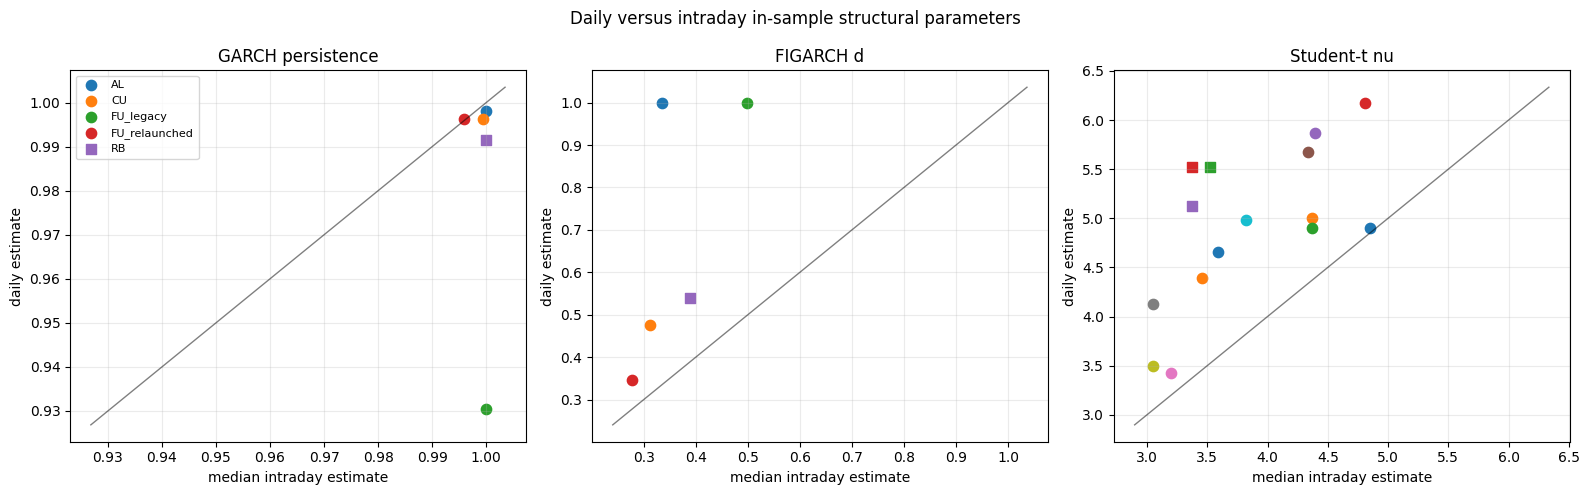

,interval_label,parameter,models,valid_t_values,significant_5pct,negative_significant_theta
0,15-min,d,5,3,2,0
1,15-min,gamma,15,12,8,0
2,15-min,nu,15,12,12,0
3,15-min,theta,15,12,12,12
4,30-min,d,5,2,1,0
5,30-min,gamma,15,12,2,0
6,30-min,nu,15,12,12,0
7,30-min,theta,15,12,2,0
8,60-min,d,5,5,5,0
9,60-min,gamma,15,15,9,0


**当前样本比较。** 日频 GARCH 持久性范围为 `0.9303`—`0.9981`；日频 FIGARCH `d` 范围为 `0.3473`—`1.0000`，相对三个盘中频率中位数的差为 `0.0705`—`0.6656`。日频 `nu` 为 `3.429`—`6.178`。稳健协方差数值门禁通过：日频 `14/15`，盘中 `39/45`。这些是入样本结构差异，不是预测胜负。

In [13]:
comparison_rows = []
for fit_row in fit_summary_df.itertuples(index=False):
    comparison_rows.extend(
        [
            {
                "series_id": fit_row.series_id,
                "interval_label": fit_row.interval_label,
                "model_family": fit_row.model_family,
                "metric": "gamma",
                "estimate": fit_row.gamma,
            },
            {
                "series_id": fit_row.series_id,
                "interval_label": fit_row.interval_label,
                "model_family": fit_row.model_family,
                "metric": "theta",
                "estimate": fit_row.theta,
            },
            {
                "series_id": fit_row.series_id,
                "interval_label": fit_row.interval_label,
                "model_family": fit_row.model_family,
                "metric": "nu",
                "estimate": fit_row.nu,
            },
        ]
    )
    if fit_row.model_family in {"GARCH", "IGARCH"}:
        comparison_rows.append(
            {
                "series_id": fit_row.series_id,
                "interval_label": fit_row.interval_label,
                "model_family": fit_row.model_family,
                "metric": "garch_persistence",
                "estimate": fit_row.garch_persistence,
            }
        )
    if fit_row.model_family == "FIGARCH":
        comparison_rows.append(
            {
                "series_id": fit_row.series_id,
                "interval_label": fit_row.interval_label,
                "model_family": fit_row.model_family,
                "metric": "figarch_d",
                "estimate": fit_row.d,
            }
        )

frequency_comparison_long_df = pd.DataFrame(comparison_rows)
frequency_comparison_df = (
    frequency_comparison_long_df.pivot(
        index=["series_id", "model_family", "metric"],
        columns="interval_label",
        values="estimate",
    )
    .reset_index()
)
frequency_comparison_df["intraday_median"] = frequency_comparison_df[
    intraday_interval_order
].median(axis=1)
frequency_comparison_df["daily_minus_intraday_median"] = (
    frequency_comparison_df["Daily"]
    - frequency_comparison_df["intraday_median"]
)

display(Markdown("### 论文品种与 FU 分段"))
display(
    frequency_comparison_df.loc[
        frequency_comparison_df["series_id"] != "RB"
    ].round(6)
)
display(Markdown("### RB 扩展"))
display(
    frequency_comparison_df.loc[
        frequency_comparison_df["series_id"] == "RB"
    ].round(6)
)

figure, axes = plt.subplots(1, 3, figsize=(16, 5))
scatter_specs = [
    ("garch_persistence", "GARCH", "GARCH persistence"),
    ("figarch_d", "FIGARCH", "FIGARCH d"),
    ("nu", None, "Student-t nu"),
]
for axis, (metric_name, family_filter, title) in zip(axes, scatter_specs):
    plot_df = frequency_comparison_df.loc[
        frequency_comparison_df["metric"] == metric_name
    ].copy()
    if family_filter is not None:
        plot_df = plot_df.loc[plot_df["model_family"] == family_filter]
    for plot_row in plot_df.itertuples(index=False):
        marker = "s" if plot_row.series_id == "RB" else "o"
        axis.scatter(
            plot_row.intraday_median,
            plot_row.Daily,
            marker=marker,
            s=55,
            label=(
                plot_row.series_id
                if family_filter is not None
                else f"{plot_row.series_id}-{plot_row.model_family}"
            ),
        )
    all_values = np.r_[
        plot_df["intraday_median"].to_numpy(),
        plot_df["Daily"].to_numpy(),
    ]
    lower_value = float(np.nanmin(all_values))
    upper_value = float(np.nanmax(all_values))
    padding = 0.05 * max(upper_value - lower_value, 1e-6)
    axis.plot(
        [lower_value - padding, upper_value + padding],
        [lower_value - padding, upper_value + padding],
        color="black",
        linewidth=1,
        alpha=0.5,
    )
    axis.set_title(title)
    axis.set_xlabel("median intraday estimate")
    axis.set_ylabel("daily estimate")
    axis.grid(alpha=0.25)
axes[0].legend(fontsize=8)
figure.suptitle("Daily versus intraday in-sample structural parameters")
figure.tight_layout()
plt.show()

significance_comparison_df = (
    parameter_result_df.loc[
        parameter_result_df["free_parameter"]
        & parameter_result_df["parameter"].isin(["gamma", "theta", "d", "nu"])
    ]
    .assign(
        significant_5pct=lambda frame: frame["p_value"].lt(0.05),
        negative_significant_theta=lambda frame: (
            frame["parameter"].eq("theta")
            & frame["estimate_model_units"].lt(0)
            & frame["p_value"].lt(0.05)
        ),
    )
    .groupby(["interval_label", "parameter"], observed=True, sort=True)
    .agg(
        models=("model_family", "size"),
        valid_t_values=("t_value", lambda values: np.isfinite(values).sum()),
        significant_5pct=("significant_5pct", "sum"),
        negative_significant_theta=("negative_significant_theta", "sum"),
    )
    .reset_index()
)
display(significance_comparison_df)

daily_persistence_comparison_df = frequency_comparison_df.loc[
    (frequency_comparison_df["metric"] == "garch_persistence")
    & (frequency_comparison_df["model_family"] == "GARCH")
]
daily_d_comparison_df = frequency_comparison_df.loc[
    frequency_comparison_df["metric"] == "figarch_d"
]
daily_nu_comparison_df = frequency_comparison_df.loc[
    frequency_comparison_df["metric"] == "nu"
]
daily_valid_covariance_count = int(
    fit_summary_df.loc[
        fit_summary_df["interval_label"] == "Daily",
        "covariance_status",
    ].eq("valid").sum()
)
intraday_valid_covariance_count = int(
    fit_summary_df.loc[
        fit_summary_df["interval_label"] != "Daily",
        "covariance_status",
    ].eq("valid").sum()
)

display(
    Markdown(
        f"**当前样本比较。** 日频 GARCH 持久性范围为 "
        f"`{daily_persistence_comparison_df['Daily'].min():.4f}`—"
        f"`{daily_persistence_comparison_df['Daily'].max():.4f}`；"
        f"日频 FIGARCH `d` 范围为 `{daily_d_comparison_df['Daily'].min():.4f}`—"
        f"`{daily_d_comparison_df['Daily'].max():.4f}`，相对三个盘中频率中位数的差为 "
        f"`{daily_d_comparison_df['daily_minus_intraday_median'].min():.4f}`—"
        f"`{daily_d_comparison_df['daily_minus_intraday_median'].max():.4f}`。"
        f"日频 `nu` 为 `{daily_nu_comparison_df['Daily'].min():.3f}`—"
        f"`{daily_nu_comparison_df['Daily'].max():.3f}`。"
        f"稳健协方差数值门禁通过：日频 `{daily_valid_covariance_count}/15`，"
        f"盘中 `{intraday_valid_covariance_count}/45`。"
        "这些是入样本结构差异，不是预测胜负。"
    )
)

## 12. 独立公式复核与验证门禁

门禁同时覆盖数据持有期、日频缩放、模型约束和推断。代表性 AL Daily GARCH 用显式循环复核 ARMA 创新，并用标准化 Student-t 的解析密度手工重算完整对数似然。

In [14]:
assert representative_daily_fit_context is not None
representative_daily_returns = representative_daily_fit_context[
    "observed_return_values"
]
representative_daily_bundle = representative_daily_fit_context["fit_bundle"]
representative_daily_parameters = representative_daily_bundle["parameters"]

representative_daily_base = (
    representative_daily_returns[1:]
    - representative_daily_parameters[0]
    - representative_daily_parameters[1] * representative_daily_returns[:-1]
)
manual_daily_innovations = np.empty_like(representative_daily_base)
manual_daily_innovations[0] = representative_daily_base[0]
for innovation_index in range(1, len(manual_daily_innovations)):
    manual_daily_innovations[innovation_index] = (
        representative_daily_base[innovation_index]
        - representative_daily_parameters[2]
        * manual_daily_innovations[innovation_index - 1]
    )
representative_daily_innovation_error = float(
    np.max(
        np.abs(
            manual_daily_innovations
            - representative_daily_bundle["innovations"]
        )
    )
)

representative_daily_nu = representative_daily_parameters[-1]
representative_daily_innovations = representative_daily_bundle["innovations"]
representative_daily_variance = representative_daily_bundle[
    "conditional_variance"
]
manual_daily_loglikelihood_terms = (
    gammaln((representative_daily_nu + 1.0) / 2.0)
    - gammaln(representative_daily_nu / 2.0)
    - 0.5 * np.log(np.pi * (representative_daily_nu - 2.0))
    - 0.5 * np.log(representative_daily_variance)
    - ((representative_daily_nu + 1.0) / 2.0)
    * np.log1p(
        np.square(representative_daily_innovations)
        / (
            representative_daily_variance
            * (representative_daily_nu - 2.0)
        )
    )
)
manual_daily_loglikelihood = float(np.sum(manual_daily_loglikelihood_terms))
optimized_daily_loglikelihood = -float(
    representative_daily_bundle["optimization_result"].fun
)
representative_daily_loglikelihood_error = abs(
    manual_daily_loglikelihood - optimized_daily_loglikelihood
)

expected_factor_count = len(series_order) * int(
    interval_spec_df.loc[
        interval_spec_df["interval_label"].isin(intraday_interval_order),
        "expected_daily_slots",
    ].sum()
)
expected_model_count = (
    len(series_order) * len(model_interval_order) * len(model_family_order)
)
daily_scaling_maximum_error = float(
    np.max(
        np.abs(
            daily_model_df["daily_model_return"] / daily_return_model_scale
            - daily_model_df["daily_log_return"]
        )
    )
)
daily_parameter_scale_audit_df = parameter_result_df.loc[
    (parameter_result_df["interval_label"] == "Daily")
    & parameter_result_df["free_parameter"]
].copy()
daily_parameter_scale_audit_df["expected_original_estimate"] = np.where(
    daily_parameter_scale_audit_df["parameter"].eq("mu"),
    daily_parameter_scale_audit_df["estimate_model_units"]
    / daily_return_model_scale,
    np.where(
        daily_parameter_scale_audit_df["parameter"].eq("omega"),
        daily_parameter_scale_audit_df["estimate_model_units"]
        / daily_return_model_scale**2,
        daily_parameter_scale_audit_df["estimate_model_units"],
    ),
)
daily_parameter_backtransform_error = float(
    np.max(
        np.abs(
            daily_parameter_scale_audit_df["expected_original_estimate"]
            - daily_parameter_scale_audit_df[
                "estimate_original_daily_log_units"
            ]
        )
    )
)

model_parameter_constraint_pass = (
    fit_summary_df["gamma"].abs().le(arma_absolute_bound + 1e-8).all()
    and fit_summary_df["theta"].abs().le(arma_absolute_bound + 1e-8).all()
    and fit_summary_df["omega"].ge(-1e-8).all()
    and fit_summary_df["nu"].gt(2).all()
)
garch_rows = fit_summary_df.loc[fit_summary_df["model_family"] == "GARCH"]
igarch_rows = fit_summary_df.loc[fit_summary_df["model_family"] == "IGARCH"]
figarch_rows = fit_summary_df.loc[fit_summary_df["model_family"] == "FIGARCH"]
garch_constraint_pass = (
    garch_rows["alpha"].ge(-1e-8).all()
    and garch_rows["beta"].ge(-1e-8).all()
    and garch_rows["garch_persistence"].le(
        garch_persistence_cap + 1e-7
    ).all()
)
igarch_constraint_pass = (
    igarch_rows["alpha"].between(-1e-8, 1.0 + 1e-8).all()
    and np.allclose(
        igarch_rows["alpha"] + igarch_rows["beta"],
        1.0,
        atol=1e-12,
        rtol=0.0,
    )
)
figarch_constraint_pass = (
    figarch_rows["d"].between(-1e-8, 1.0 + 1e-8).all()
    and figarch_rows["phi"].ge(-1e-8).all()
    and (2 * figarch_rows["phi"] + figarch_rows["d"]).le(1.0 + 1e-7).all()
    and figarch_rows["beta"].ge(-1e-8).all()
    and figarch_rows["beta"].le(
        figarch_rows["d"] + figarch_rows["phi"] + 1e-7
    ).all()
)

fu_legacy_full_end = daily_return_df.loc[
    daily_return_df["series_id"] == "FU_legacy",
    "trading_date",
].max()
fu_relaunched_full_start = daily_return_df.loc[
    daily_return_df["series_id"] == "FU_relaunched",
    "trading_date",
].min()

validation_gate_df = pd.DataFrame(
    [
        ("latitude_environment", current_python == expected_python, str(current_python)),
        (
            "source_schema_physical_compatibility",
            source_contract_audit_df["physical_mismatch_count"].eq(0).all(),
            ", ".join(source_contract_audit_df["table_name"]),
        ),
        (
            "unique_trade_month_plus_three_contract",
            contract_mapping_audit_df["target_contract_count"].isin([0, 1]).all()
            and contract_series_df["contract_code"].eq(
                contract_series_df["expected_contract_code"]
            ).all()
            and actual_missing_keys_df.equals(known_missing_keys_df),
            "唯一固定三个月合约；仅排除 22 日 FU1102.XSGE 未上市缺口",
        ),
        (
            "day_sessions_and_minute_alignment",
            not contract_calendar_df["is_night_session"].any()
            and not bar_calendar_df["is_night_session"].any()
            and complete_contract_day_df["is_complete_contract_day"].all()
            and minute_read_audit_df["session_alignment_failures"].eq(0).all(),
            f"{len(complete_contract_day_df):,} 合约日；{int(minute_read_audit_df['selected_day_minute_rows'].sum()):,} 日盘分钟",
        ),
        (
            "intraday_and_daily_slot_structure",
            slot_audit_df[
                [
                    "slot_count_failures",
                    "aggregated_minute_count_failures",
                    "non_last_slot_length_failures",
                    "last_slot_length_failures",
                ]
            ].eq(0).all().all(),
            "每日 15/8/4/1 槽；Daily 槽严格 225 分钟",
        ),
        (
            "daily_return_cross_frequency_identity",
            len(daily_return_df) == len(complete_contract_day_df)
            and daily_return_df["actual_interval_minutes"].eq(225).all()
            and daily_consistency_df[
                daily_consistency_error_columns
            ].abs().max().max() < 1e-15,
            f"{len(daily_return_df):,} 日收益；最大跨频率差={daily_consistency_df[daily_consistency_error_columns].abs().max().max():.3e}",
        ),
        (
            "daily_not_deseasonalized_and_scale_reversible",
            "seasonality_factor" not in daily_model_df.columns
            and daily_scaling_maximum_error <= np.finfo(float).eps
            and daily_parameter_backtransform_error <= np.finfo(float).eps,
            f"收益缩放误差={daily_scaling_maximum_error:.3e}; 参数回缩误差={daily_parameter_backtransform_error:.3e}",
        ),
        (
            "intraday_full_sample_seasonality_factors",
            len(seasonality_factor_df) == expected_factor_count
            and np.isfinite(seasonality_factor_df["seasonality_factor"]).all()
            and seasonality_factor_df["seasonality_factor"].gt(0).all()
            and full_sample_factor_audit_df[
                "mean_squared_deseasonalized_return"
            ].sub(1.0).abs().max() < 1e-12,
            f"{len(seasonality_factor_df)} 个盘中全文样本因子；每槽 mean(r_tilde^2)=1",
        ),
        (
            "initial_and_oos_day_counts",
            model_sample_df.set_index("series_id")["oos_days"].to_dict()
            == {"AL": 300, "CU": 300, "FU_legacy": 200, "FU_relaunched": 200, "RB": 300}
            and daily_panel_audit_df.set_index("series_id")["input_returns"].to_dict()
            == {"AL": 3745, "CU": 3745, "FU_legacy": 204, "FU_relaunched": 1414, "RB": 3745},
            "; ".join(
                f"{row.series_id}: initial={row.initial_sample_days}, OOS={row.oos_days}"
                for row in model_sample_df.itertuples(index=False)
            ),
        ),
        (
            "arma_filter_manual_recursion",
            manual_filter_maximum_error < 1e-14
            and representative_daily_innovation_error < 1e-12,
            f"小样本误差={manual_filter_maximum_error:.3e}; AL Daily误差={representative_daily_innovation_error:.3e}",
        ),
        (
            "student_t_manual_loglikelihood",
            representative_daily_loglikelihood_error < 1e-8,
            f"AL Daily GARCH 手工对数似然误差={representative_daily_loglikelihood_error:.3e}",
        ),
        (
            "complete_daily_and_intraday_model_grid",
            len(fit_summary_df) == expected_model_count
            and fit_summary_df["interval_label"].eq("Daily").sum() == 15
            and fit_summary_df["interval_label"].ne("Daily").sum() == 45
            and fit_summary_df["success"].all()
            and fit_summary_df["is_feasible"].all()
            and fit_summary_df["minimum_constraint_slack"].ge(
                -optimization_feasibility_tolerance
            ).all(),
            "15 个日频 + 45 个盘中模型；全部选择成功且可行的起点",
        ),
        (
            "conditional_variances_finite_positive",
            fit_summary_df["minimum_conditional_variance_model_units"].gt(0).all()
            and np.isfinite(
                fit_summary_df[
                    [
                        "minimum_conditional_variance_model_units",
                        "maximum_conditional_variance_model_units",
                        "loglikelihood",
                    ]
                ].to_numpy()
            ).all(),
            "60 个模型的条件方差有限且严格为正",
        ),
        (
            "model_parameter_constraints",
            model_parameter_constraint_pass
            and garch_constraint_pass
            and igarch_constraint_pass
            and figarch_constraint_pass,
            "ARMA 边界、GARCH 严格帽、IGARCH 等式与 FIGARCH arch 可行域均通过",
        ),
        (
            "standardized_student_t_only",
            fit_summary_df["nu"].gt(2).all()
            and len(
                parameter_result_df.loc[
                    (parameter_result_df["parameter"] == "nu")
                    & parameter_result_df["free_parameter"]
                ]
            ) == expected_model_count,
            "60 个模型均估计 nu；日频未切换正态",
        ),
        (
            "figarch_truncation_1000",
            len(figarch_rows) == 20
            and figarch_rows["figarch_truncation"].eq(figarch_truncation).all(),
            f"20 个 FIGARCH 均为 truncation={figarch_truncation}",
        ),
        (
            "covariance_diagnostics_explicit",
            fit_summary_df["covariance_status"].notna().all()
            and parameter_result_df["covariance_status"].notna().all(),
            f"有效稳健协方差 {fit_summary_df['covariance_status'].eq('valid').sum()}/60；其余显式标记，不使用伪逆",
        ),
        (
            "fu_legacy_short_sample_explicit",
            fu_legacy_daily_diagnostic_df["likelihood_observations"].eq(203).all()
            and len(fu_legacy_daily_diagnostic_df) == 3,
            "FU_legacy 日频仅 203 个似然观察；边界、候选差与 Hessian 状态已单列",
        ),
        (
            "fu_segments_are_independent",
            fu_legacy_full_end < fu_relaunched_full_start
            and set(fit_summary_df.loc[fit_summary_df["series_id"].str.startswith("FU"), "series_id"]) == {"FU_legacy", "FU_relaunched"},
            f"legacy_end={fu_legacy_full_end.date()}, relaunched_start={fu_relaunched_full_start.date()}",
        ),
        (
            "rb_extension_is_separate",
            sample_spec_df.loc[
                sample_spec_df["series_id"] == "RB", "research_role"
            ].eq("论文外扩展品种").all()
            and len(fit_summary_df.loc[fit_summary_df["series_id"] == "RB"]) == 12,
            "RB 的 Daily + 三个盘中频率共 12 个模型独立列示",
        ),
    ],
    columns=["gate", "passed", "evidence"],
)

display(validation_gate_df)
assert validation_gate_df["passed"].all(), validation_gate_df.loc[
    ~validation_gate_df["passed"]
]

,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,source_schema_physical_compatibility,True,"dim_futures_variety_calendar, dim_futures_contract_calendar, dim_futures_bar_calendar, fact_futures_minute"
2,unique_trade_month_plus_three_contract,True,唯一固定三个月合约；仅排除 22 日 FU1102.XSGE 未上市缺口
3,day_sessions_and_minute_alignment,True,"14,153 合约日；3,184,425 日盘分钟"
4,intraday_and_daily_slot_structure,True,每日 15/8/4/1 槽；Daily 槽严格 225 分钟
5,daily_return_cross_frequency_identity,True,"14,153 日收益；最大跨频率差=1.388e-17"
6,daily_not_deseasonalized_and_scale_reversible,True,收益缩放误差=1.388e-17; 参数回缩误差=1.084e-19
7,intraday_full_sample_seasonality_factors,True,135 个盘中全文样本因子；每槽 mean(r_tilde^2)=1
8,initial_and_oos_day_counts,True,"AL: initial=3745, OOS=300; CU: initial=3745, OOS=300; FU_legacy: initial=204, OOS=200; FU_relaunched: initial=1414, OOS=200; RB: initial=3745, OOS=300"
9,arma_filter_manual_recursion,True,小样本误差=0.000e+00; AL Daily误差=0.000e+00


## 13. 结果解释与限制

解释时遵循以下边界：

1. 日频 `α+β` 接近 1 表示 Session 内日收益的波动冲击跨观察日衰减缓慢；它不等同于包含隔夜持有期的论文日收益结论。
2. FIGARCH `d>0` 是当前可行域内的长记忆证据。若估计贴近 0/1、Hessian 无效或短 FU 样本 t 值缺失，不作强显著性结论。
3. 日频 `ν` 高于盘中 `ν` 可解释为时间聚合后尾部相对变薄，但两者信息集和缩放不同，不能比较 `ω` 或条件方差水平。
4. `γ` 与 `θ` 接近相反数时可能是 ARMA 近抵消；尤其 FU_legacy 只有 203 个日频似然观察，应优先看候选解、边界和 Hessian，而不是机械读星号。
5. RB 仅作为扩展检验；两个 FU 分段不得合并。

已知限制：

- 项目日收益不含隔夜和 Session 间跳空，与论文 close-to-close 定义不同；这是遵守项目既定风险持有期后的有意偏离。
- 日频乘 100 只是优化单位，未来日频方差预测必须除以 10,000 回到与 RV/MedRV/Parkinson 相同的对数方差单位。
- 论文未披露日价格字段、换月复权、优化器、回溯方差、FIGARCH 截断与协方差；本 Notebook 逐项公开项目选择。
- 论文 fuel oil 日频 FIGARCH 的负 `φ` 与当前 `arch` 非负可行域不一致；本项目不会为追逐论文数值放宽已冻结约束。
- 本项比较的是入样本参数。作者关于“日频预测不差于盘中预测”的结论不能在本项验证，必须等待共同 OOS 预测与损失检验。